### Imports

In [1]:
import pandas as pd
import numpy as np
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import ScalarFormatter

### Load Cleaned Dataset

In [2]:
df = pd.read_csv("../dataset/ga_sessions_flat.csv",low_memory = False)

In [3]:
df.info(memory_usage = "deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 903653 entries, 0 to 903652
Data columns (total 24 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   fullVisitorId    903653 non-null  object 
 1   visitId          903653 non-null  int64  
 2   visitNumber      903653 non-null  int64  
 3   date             903653 non-null  object 
 4   channelGrouping  903653 non-null  object 
 5   deviceCategory   903653 non-null  object 
 6   browser          903653 non-null  object 
 7   operatingSystem  903653 non-null  object 
 8   isMobile         903653 non-null  bool   
 9   continent        903653 non-null  object 
 10  subContinent     903653 non-null  object 
 11  country          903653 non-null  object 
 12  pageviews        903653 non-null  int64  
 13  bounces          903653 non-null  int64  
 14  hits             903653 non-null  int64  
 15  newVisits        903653 non-null  int64  
 16  source           903653 non-null  obje

In [4]:
df["date"] = pd.to_datetime(df["date"])

for col in ["pageviews","bounces", "hits", "newVisits"]:
    df[col] = df[col].astype("int32")

for col in ["channelGrouping", "deviceCategory", "browser", "operatingSystem", "continent", "subContinent", "country", "source", "medium","campaign", "YearMonth", "FunnelStage"]:
    df[col] = df[col].astype("category")

for col in ["IsCustomer","IsLead"]:
    df[col] = df[col].astype("int8")

In [5]:
df.info(memory_usage = "deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 903653 entries, 0 to 903652
Data columns (total 24 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   fullVisitorId    903653 non-null  object        
 1   visitId          903653 non-null  int64         
 2   visitNumber      903653 non-null  int64         
 3   date             903653 non-null  datetime64[ns]
 4   channelGrouping  903653 non-null  category      
 5   deviceCategory   903653 non-null  category      
 6   browser          903653 non-null  category      
 7   operatingSystem  903653 non-null  category      
 8   isMobile         903653 non-null  bool          
 9   continent        903653 non-null  category      
 10  subContinent     903653 non-null  category      
 11  country          903653 non-null  category      
 12  pageviews        903653 non-null  int32         
 13  bounces          903653 non-null  int32         
 14  hits             903

In [6]:
df.head()

,fullVisitorId,visitId,visitNumber,date,channelGrouping,deviceCategory,browser,operatingSystem,isMobile,continent,...,hits,newVisits,source,medium,campaign,Revenue,YearMonth,IsCustomer,IsLead,FunnelStage
0,1131660440785968503,1472830385,1,2016-09-02,Organic Search,desktop,Chrome,Windows,False,Asia,...,1,1,google,organic,Unknown,0.0,2016-09,0,0,Visitor Only
1,377306020877927890,1472880147,1,2016-09-02,Organic Search,desktop,Firefox,Macintosh,False,Oceania,...,1,1,google,organic,Unknown,0.0,2016-09,0,0,Visitor Only
2,3895546263509774583,1472865386,1,2016-09-02,Organic Search,desktop,Chrome,Windows,False,Europe,...,1,1,google,organic,Unknown,0.0,2016-09,0,0,Visitor Only
3,4763447161404445595,1472881213,1,2016-09-02,Organic Search,desktop,UC Browser,Linux,False,Asia,...,1,1,google,organic,Unknown,0.0,2016-09,0,0,Visitor Only
4,27294437909732085,1472822600,2,2016-09-02,Organic Search,mobile,Chrome,Android,True,Europe,...,1,0,google,organic,Unknown,0.0,2016-09,0,0,Visitor Only


In [7]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 903653
Columns: 24


In [8]:
missing = df.isnull().sum()
missing[missing > 0]

Series([], dtype: int64)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["visitId"].duplicated().sum()

np.int64(17350)

In [11]:
print("Minimum date:", df["date"].min())
print("Maximum date:", df["date"].max())

Minimum date: 2016-08-01 00:00:00
Maximum date: 2017-08-01 00:00:00


In [12]:
print(f"Visitor Only : {(df["FunnelStage"] == "Visitor Only").sum()}")
print(f"Lead : {(df["FunnelStage"] == "Lead").sum()}")
print(f"Customer : {(df["FunnelStage"] == "Customer").sum()}")

Visitor Only : 450630
Lead : 441508
Customer : 11515


In [13]:
print("Total Revenue:", f"{df["Revenue"].sum():.2f}")

Total Revenue: 1540071.24


In [14]:
funnel_counts = df["FunnelStage"].value_counts()

print(funnel_counts)

print("\nTotal funnel records:", funnel_counts.sum())
print("Total dataframe records:", len(df))

print("\nDifference:", len(df) - funnel_counts.sum())

FunnelStage
Visitor Only    450630
Lead            441508
Customer         11515
Name: count, dtype: int64

Total funnel records: 903653
Total dataframe records: 903653

Difference: 0


## Exploratory Data Analysis

### Funnel Analysis

In [15]:
total_sessions = len(df)
lead_sessions = df["IsLead"].sum()
customer_sessions = df["IsCustomer"].sum()

print("Total Sessions:", total_sessions)
print("Lead Sessions:", lead_sessions)
print("Customer Sessions:", customer_sessions)

Total Sessions: 903653
Lead Sessions: 453023
Customer Sessions: 11515


In [16]:
visitor_to_lead = (lead_sessions / total_sessions) * 100
lead_to_customer = (customer_sessions / lead_sessions) * 100

print(f"Visitor → Lead Conversion: {visitor_to_lead:.2f}%")
print(f"Lead → Customer Conversion: {lead_to_customer:.2f}%")

Visitor → Lead Conversion: 50.13%
Lead → Customer Conversion: 2.54%


In [17]:
visitor_to_lead_dropoff = total_sessions - lead_sessions
lead_to_customer_dropoff = lead_sessions - customer_sessions

visitor_to_lead_dropoff_pct = (
    visitor_to_lead_dropoff / total_sessions
) * 100

lead_to_customer_dropoff_pct = (
    lead_to_customer_dropoff / lead_sessions
) * 100

print(f"Visitor → Lead Drop-off: {visitor_to_lead_dropoff_pct:.2f}%")
print(f"Lead → Customer Drop-off: {lead_to_customer_dropoff_pct:.2f}%")

Visitor → Lead Drop-off: 49.87%
Lead → Customer Drop-off: 97.46%


#### Conversion and Drop off analysis

In [18]:
conversion_dropoff_df = pd.DataFrame({
    "Funnel Transition": [
        "Visitor → Lead",
        "Lead → Customer"
    ],
    "Conversion Sessions" : [
        lead_sessions,
        customer_sessions
    ],
    "Conversion Rate (%)" : [
        visitor_to_lead,
        lead_to_customer
    ],
    "Drop-off Sessions": [
        visitor_to_lead_dropoff,
        lead_to_customer_dropoff
    ],
    "Drop-off Rate (%)": [
        visitor_to_lead_dropoff_pct,
        lead_to_customer_dropoff_pct
    ]
})

display(conversion_dropoff_df)

,Funnel Transition,Conversion Sessions,Conversion Rate (%),Drop-off Sessions,Drop-off Rate (%)
0,Visitor → Lead,453023,50.132407,450630,49.867593
1,Lead → Customer,11515,2.541814,441508,97.458186


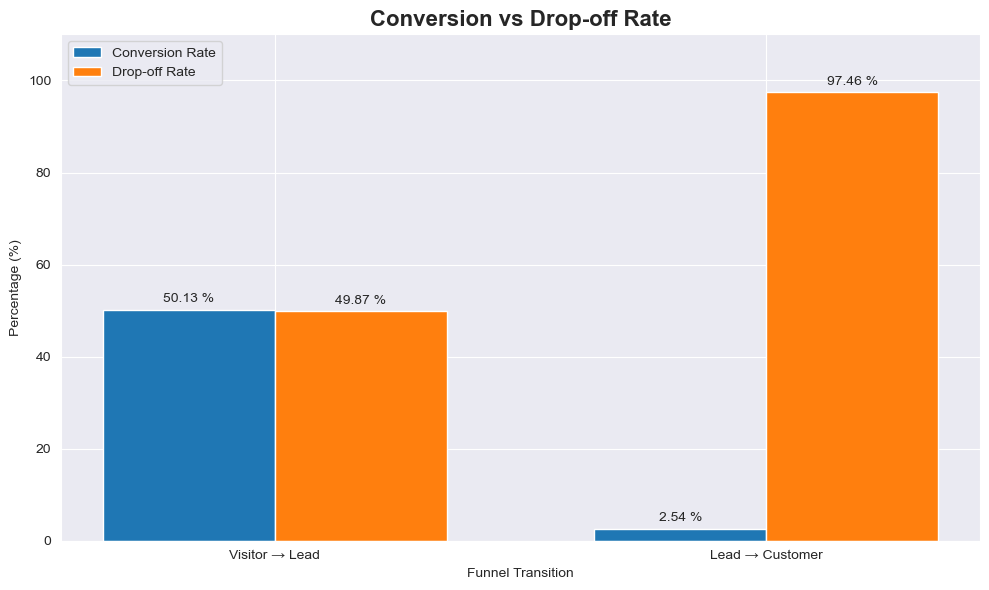

In [19]:
transitions = ["Visitor → Lead", "Lead → Customer"]

x = np.arange(len(transitions))
width = 0.35

sns.set_style("darkgrid")

plt.figure(figsize = (10,6))

bars1 = plt.bar(x - width/2, conversion_dropoff_df["Conversion Rate (%)"], width, label = "Conversion Rate")

bars2 = plt.bar(x + width/2, conversion_dropoff_df["Drop-off Rate (%)"], width, label = "Drop-off Rate")

plt.title("Conversion vs Drop-off Rate", fontsize=16, fontweight="bold")
plt.xlabel("Funnel Transition")
plt.ylabel("Percentage (%)")
plt.xticks(x, transitions)
plt.ylim(0,110)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 1,
            f"{height:.2f} %",
            ha = "center",
            va = "bottom",
            fontsize = 10
        )

plt.legend()
plt.tight_layout()
plt.show()

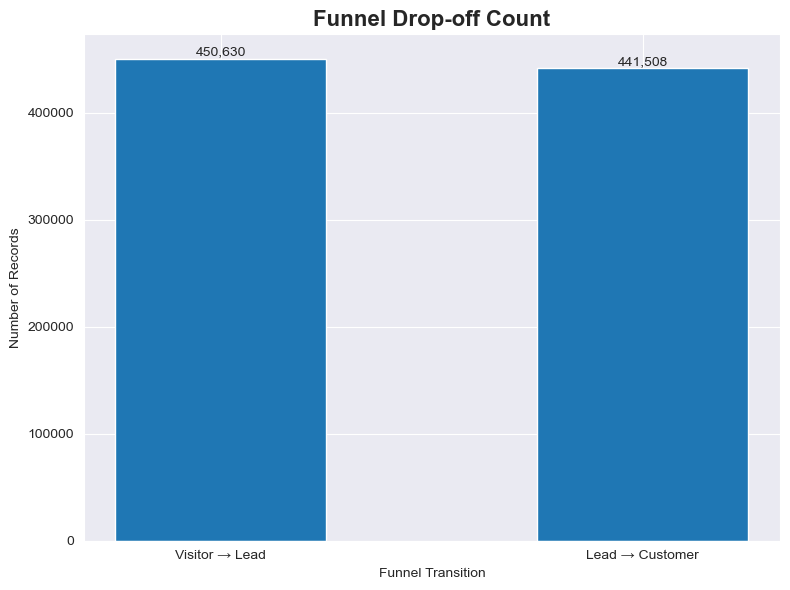

In [20]:
plt.figure(figsize=(8, 6))

bars = plt.bar(transitions, conversion_dropoff_df["Drop-off Sessions"], width = 0.5)

plt.title("Funnel Drop-off Count", fontsize=16, fontweight="bold")
plt.xlabel("Funnel Transition")
plt.ylabel("Number of Records")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha = "center",
        va = "bottom",
        fontsize = 10
    )

plt.tight_layout()
plt.show()

#### Channel wise conversion

In [21]:
channel_counts = df["channelGrouping"].value_counts()
channel_counts

channelGrouping
Organic Search    381561
Social            226117
Direct            143026
Referral          104838
Paid Search        25326
Affiliates         16403
Display             6262
(Other)              120
Name: count, dtype: int64

In [22]:
channel_distribution = df["channelGrouping"].value_counts(normalize = True).mul(100).round(2)

channel_distribution

channelGrouping
Organic Search    42.22
Social            25.02
Direct            15.83
Referral          11.60
Paid Search        2.80
Affiliates         1.82
Display            0.69
(Other)            0.01
Name: proportion, dtype: float64

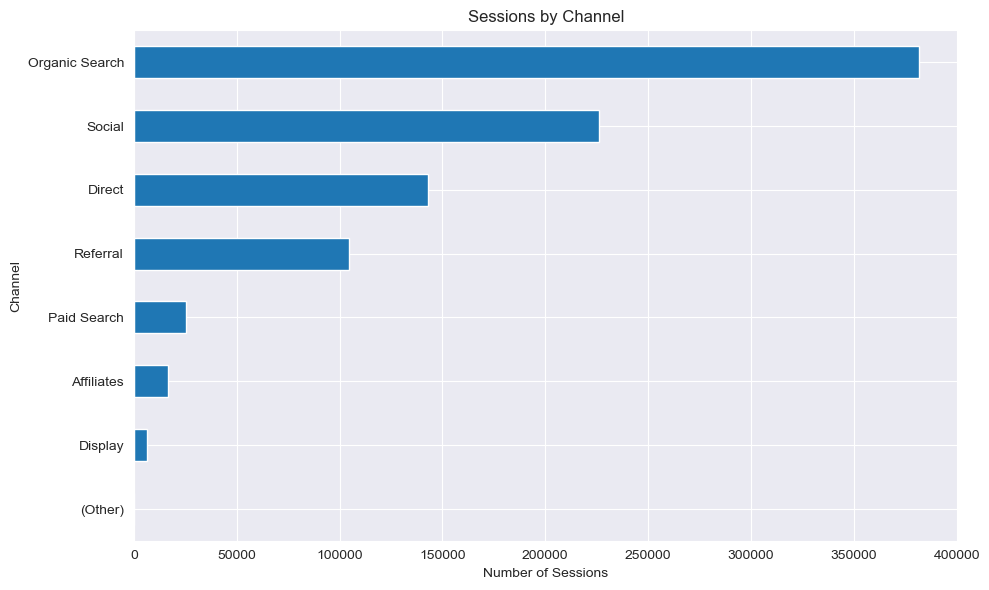

In [23]:
plt.figure(figsize=(10, 6))

channel_counts.sort_values().plot(kind="barh")

plt.xlabel("Number of Sessions")
plt.ylabel("Channel")
plt.title("Sessions by Channel")

plt.tight_layout()
plt.show()

In [24]:
channel_analysis = (
    df.groupby("channelGrouping", observed=True)
    .agg(
        Visitor = ("visitId", "count"),
        Lead = ("IsLead", "sum"),
        Customer = ("IsCustomer", "sum")
    )
    .reset_index()
)
channel_analysis

,channelGrouping,Visitor,Lead,Customer
0,(Other),120,64,1
1,Affiliates,16403,7702,9
2,Direct,143026,72144,2042
3,Display,6262,4016,142
4,Organic Search,381561,197191,3438
5,Paid Search,25326,15699,468
6,Referral,104838,77599,5311
7,Social,226117,78608,104


In [25]:
channel_analysis["Customer_Conversion_Rate"] = (channel_analysis["Customer"] / channel_analysis["Visitor"] * 100).round(2)

channel_analysis["Customer_Contribution"] = (channel_analysis["Customer"] / channel_analysis["Customer"].sum() * 100).round(2)

channel_analysis

,channelGrouping,Visitor,Lead,Customer,Customer_Conversion_Rate,Customer_Contribution
0,(Other),120,64,1,0.83,0.01
1,Affiliates,16403,7702,9,0.05,0.08
2,Direct,143026,72144,2042,1.43,17.73
3,Display,6262,4016,142,2.27,1.23
4,Organic Search,381561,197191,3438,0.90,29.86
5,Paid Search,25326,15699,468,1.85,4.06
6,Referral,104838,77599,5311,5.07,46.12
7,Social,226117,78608,104,0.05,0.90


In [26]:
channel_analysis = channel_analysis[
    [
        "channelGrouping",
        "Visitor",
        "Lead",
        "Customer",
        "Customer_Conversion_Rate",
        "Customer_Contribution"
    ]
]

channel_analysis = channel_analysis.sort_values(
    "Customer",
    ascending=False
).reset_index(drop = True)

channel_analysis.columns = [
    "Channel",
    "Total Sessions",
    "Lead Sessions",
    "Customer Sessions",
    "Customer Conversion Rate (%)",
    "Customer Contribution (%)"
]

channel_analysis

,Channel,Total Sessions,Lead Sessions,Customer Sessions,Customer Conversion Rate (%),Customer Contribution (%)
0,Referral,104838,77599,5311,5.07,46.12
1,Organic Search,381561,197191,3438,0.90,29.86
2,Direct,143026,72144,2042,1.43,17.73
3,Paid Search,25326,15699,468,1.85,4.06
4,Display,6262,4016,142,2.27,1.23
5,Social,226117,78608,104,0.05,0.90
6,Affiliates,16403,7702,9,0.05,0.08
7,(Other),120,64,1,0.83,0.01


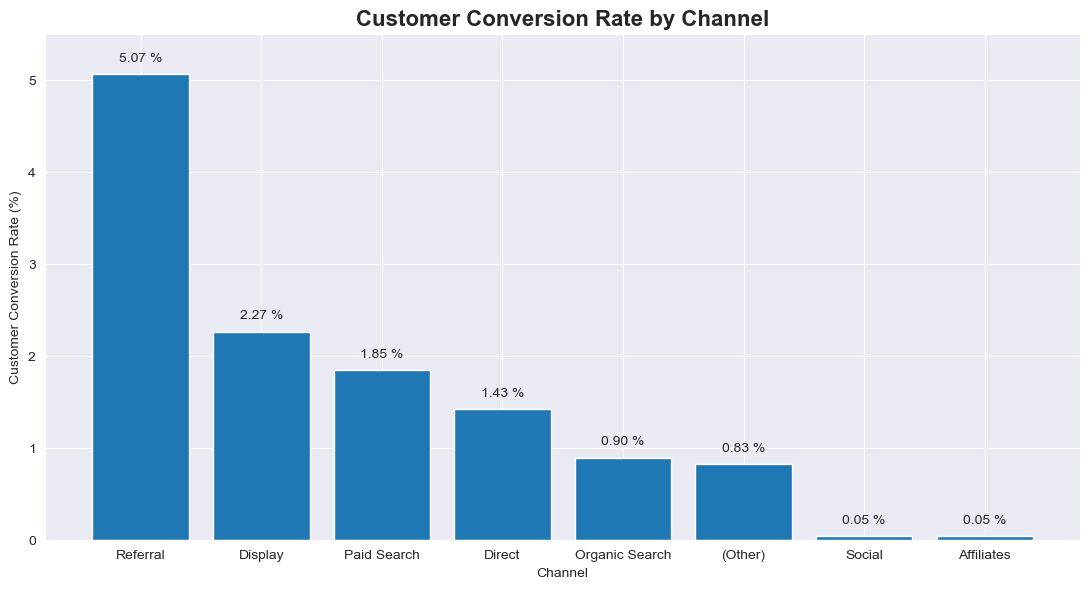

In [27]:
# Customer Conversion Rate by Channel
plot_df = channel_analysis.sort_values("Customer Conversion Rate (%)", ascending = False)
plt.figure(figsize = (11,6))

bars = plt.bar(
    plot_df["Channel"],
    plot_df["Customer Conversion Rate (%)"]
)

plt.title("Customer Conversion Rate by Channel", fontsize=16, fontweight="bold")
plt.xlabel("Channel")
plt.ylabel("Customer Conversion Rate (%)")
plt.ylim(0,5.5)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.1,
        f"{height:.2f} %",
        ha = "center",
        va = "bottom",
        fontsize = 10
    )

plt.tight_layout()
plt.show()

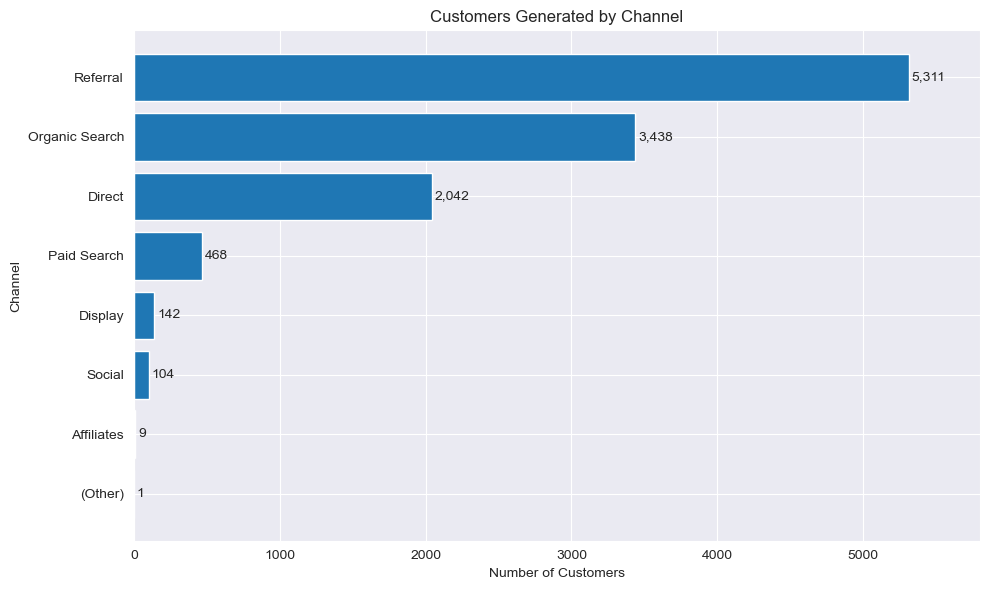

In [28]:
# Customers by Channel 
plot_df = channel_analysis.sort_values("Customer Sessions", ascending = True)
plt.figure(figsize = (10,6))

bars = plt.barh(plot_df["Channel"], plot_df["Customer Sessions"])

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 20,
        bar.get_y() + bar.get_height()/2,
        f"{int(width):,}",
        ha = "left",
        va = "center"
    )

plt.xlim(0,5800)
plt.xlabel("Number of Customers")
plt.ylabel("Channel")
plt.title("Customers Generated by Channel")

plt.tight_layout()
plt.show()

In [29]:
channel_analysis.sort_values("Total Sessions", ascending = False).head(1)

,Channel,Total Sessions,Lead Sessions,Customer Sessions,Customer Conversion Rate (%),Customer Contribution (%)
1,Organic Search,381561,197191,3438,0.9,29.86


In [30]:
channel_analysis.sort_values("Customer Sessions", ascending = False).head(1)

,Channel,Total Sessions,Lead Sessions,Customer Sessions,Customer Conversion Rate (%),Customer Contribution (%)
0,Referral,104838,77599,5311,5.07,46.12


The channel analysis shows that Referral is the strongest-performing channel, generating 5,311 customers with a 5.07% customer conversion rate and contributing 46.12% of total customers. Organic Search generated the highest number of sessions (381,561) and contributed 29.86% of customers, but its customer conversion rate was only 0.90%. Direct also performed well, contributing 17.73% of customers with a 1.43% conversion rate. In contrast, Social generated substantial traffic but had a very low customer conversion rate of 0.05%. Overall, the results show that high traffic volume does not necessarily translate into high customer conversion.

#### Source & Medium analysis

In [31]:
print("Number of unique mediums:", df["medium"].nunique())

medium_counts = df["medium"].value_counts()

print("\nMedium distribution:")
print(medium_counts)

Number of unique mediums: 7

Medium distribution:
medium
organic      381561
referral     330955
(none)       143026
cpc           25326
affiliate     16403
cpm            6262
Unknown         120
Name: count, dtype: int64


In [32]:
medium_distribution = df["medium"].value_counts(normalize = True).mul(100).round(2)
medium_distribution

medium
organic      42.22
referral     36.62
(none)       15.83
cpc           2.80
affiliate     1.82
cpm           0.69
Unknown       0.01
Name: proportion, dtype: float64

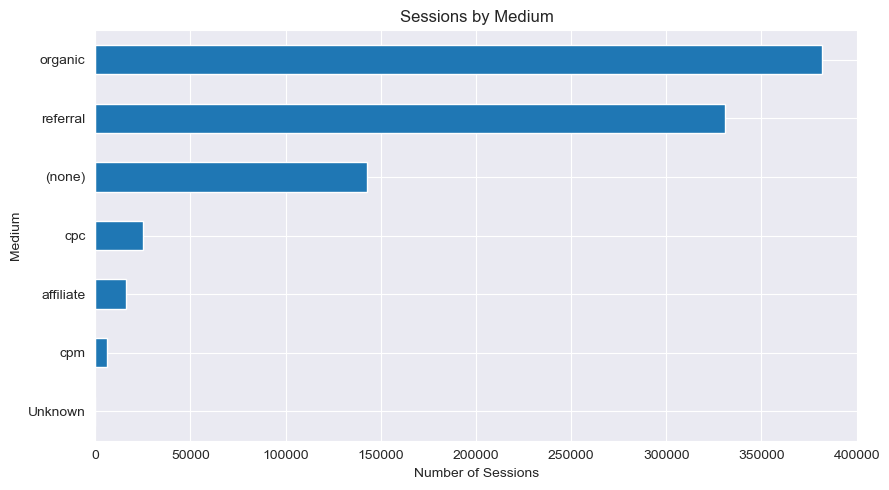

In [33]:
plt.figure(figsize=(9, 5))

medium_counts.sort_values().plot(kind="barh")

plt.xlabel("Number of Sessions")
plt.ylabel("Medium")
plt.title("Sessions by Medium")

plt.tight_layout()
plt.show()

In [34]:
medium_analysis = (
    df.groupby("medium", observed = True)
    .agg(
        Total_Sessions = ("IsCustomer", "size"),
        Lead_Sessions = ("IsLead", "sum"), 
        Customer_Sessions = ("IsCustomer", "sum")
    )
    .reset_index()
)

medium_analysis["Customer Conversion Rate (%)"] = (medium_analysis["Customer_Sessions"]/ medium_analysis["Total_Sessions"] * 100).round(2)
medium_analysis["Customer Contribution Rate (%)"] = (medium_analysis["Customer_Sessions"] / medium_analysis["Customer_Sessions"].sum() * 100).round(2)

In [35]:
medium_analysis = medium_analysis.sort_values(
    "Customer_Sessions",
    ascending=False
).reset_index(drop = True)

medium_analysis

,medium,Total_Sessions,Lead_Sessions,Customer_Sessions,Customer Conversion Rate (%),Customer Contribution Rate (%)
0,referral,330955,156207,5415,1.64,47.03
1,organic,381561,197191,3438,0.90,29.86
2,(none),143026,72144,2042,1.43,17.73
3,cpc,25326,15699,468,1.85,4.06
4,cpm,6262,4016,142,2.27,1.23
5,affiliate,16403,7702,9,0.05,0.08
6,Unknown,120,64,1,0.83,0.01


In [36]:
print("Number of unique sources:", df["source"].nunique())

top_sources = df["source"].value_counts().head(10)

print("\nTop 10 Sources by Record Count:")
print(top_sources)

Number of unique sources: 380

Top 10 Sources by Record Count:
source
google                  400788
youtube.com             212602
(direct)                143028
mall.googleplex.com      66416
Partners                 16411
analytics.google.com     16172
dfa                       5686
google.com                4669
m.facebook.com            3365
baidu                     3356
Name: count, dtype: int64


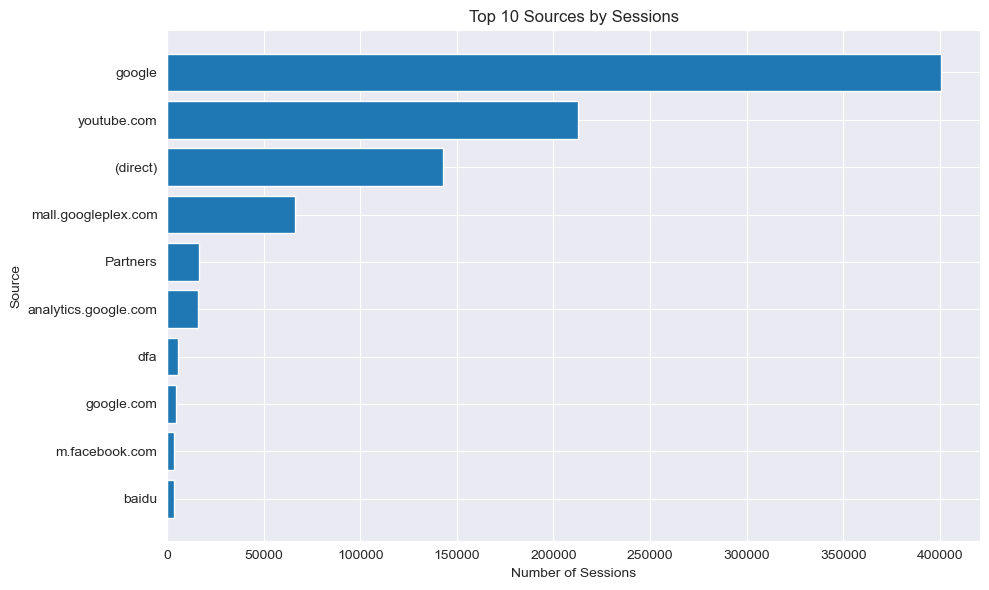

In [37]:
plt.figure(figsize=(10, 6))

plt.barh(top_sources.sort_values().index, top_sources.sort_values().values)

plt.xlabel("Number of Sessions")
plt.ylabel("Source")
plt.title("Top 10 Sources by Sessions")

plt.tight_layout()
plt.show()

In [38]:
source_customer_analysis = (
    df.groupby("source", observed = True)
    .agg(
        Total_Sessions = ("IsCustomer", "size"),
        Lead_Sessions = ("IsLead", "sum"), 
        Customer_Sessions = ("IsCustomer", "sum")
    )
    .reset_index()
)

source_customer_analysis["Customer Conversion Rate (%)"] = (source_customer_analysis["Customer_Sessions"] / source_customer_analysis["Total_Sessions"] * 100).round(2)
source_customer_analysis["Customer Contribution (%)"] = (
    source_customer_analysis["Customer_Sessions"]
    / source_customer_analysis["Customer_Sessions"].sum()
    * 100
).round(2)

source_customer_analysis = source_customer_analysis.sort_values(
    "Customer_Sessions",
    ascending=False
).reset_index(drop = True)

top_customer_sources = source_customer_analysis.head(10)

top_customer_sources

,source,Total_Sessions,Lead_Sessions,Customer_Sessions,Customer Conversion Rate (%),Customer Contribution (%)
0,mall.googleplex.com,66416,56948,5103,7.68,44.32
1,google,400788,210363,3879,0.97,33.69
2,(direct),143028,72144,2042,1.43,17.73
3,dfa,5686,3635,123,2.16,1.07
4,mail.google.com,1457,910,62,4.26,0.54
5,sites.google.com,2983,1985,42,1.41,0.36
6,dealspotr.com,528,257,40,7.58,0.35
7,groups.google.com,1025,594,38,3.71,0.33
8,yahoo,1480,805,22,1.49,0.19
9,bing,1530,890,21,1.37,0.18


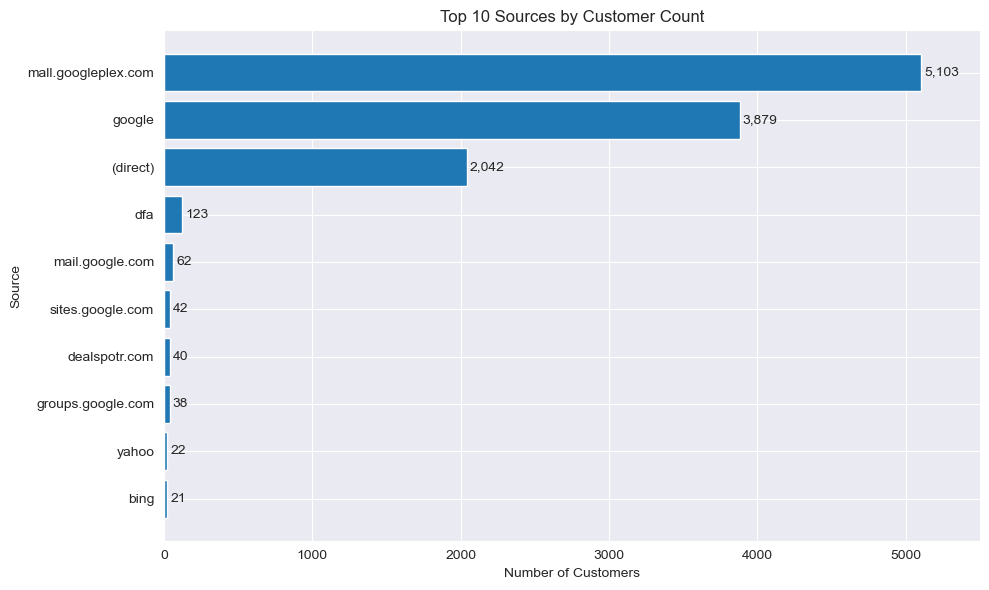

In [39]:
plot_df = top_customer_sources.sort_values(
    "Customer_Sessions"
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    plot_df["source"],
    plot_df["Customer_Sessions"]
)

plt.xlabel("Number of Customers")
plt.ylabel("Source")
plt.title("Top 10 Sources by Customer Count")
plt.xlim(0, 5500)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 20,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,}",
        va="center",
        ha="left"
    )

plt.tight_layout()
plt.show()

The source and medium analysis shows that Referral is the strongest medium in terms of customer contribution, generating 47.03% of all customers. Organic has the highest traffic volume with 381,561 sessions but a lower customer conversion rate of 0.90%. At the source level, Google generated the highest number of sessions (400,788), whereas mall.googleplex.com generated the highest number of customers (5,103) among the analyzed sources. The mall.googleplex.com source also had a substantially higher customer conversion rate of 7.68% compared with Google's 0.97%. These results demonstrate that high traffic volume does not necessarily correspond to high customer conversion.

#### Device & User Analysis

In [40]:
# device category overview
device_counts = df["deviceCategory"].value_counts()
device_counts

deviceCategory
desktop    664479
mobile     208725
tablet      30449
Name: count, dtype: int64

In [41]:
device_distribution = df["deviceCategory"].value_counts(normalize = True).mul(100).round(2)
device_distribution

deviceCategory
desktop    73.53
mobile     23.10
tablet      3.37
Name: proportion, dtype: float64

In [42]:
device_overview = pd.DataFrame({
    "Records": df["deviceCategory"].value_counts(),
    "Percentage": df["deviceCategory"].value_counts(normalize=True).mul(100).round(2)
})

device_overview

,Records,Percentage
deviceCategory,,
desktop,664479,73.53
mobile,208725,23.10
tablet,30449,3.37


In [96]:
device_analysis = (
    df.groupby("deviceCategory", observed = True)
    .agg(
        Total_Sessions = ("IsCustomer", "size"),
        Lead_Sessions = ("IsLead", "sum"),
        Customer_Sessions = ("IsCustomer" , "sum")
    )
    .reset_index()
)

device_analysis["Customer Conversion Rate (%)"] = (device_analysis["Customer_Sessions"] / device_analysis["Total_Sessions"] * 100).round(2)
device_analysis["Customer Contribution (%)"] = (device_analysis["Customer_Sessions"] / device_analysis["Customer_Sessions"].sum() * 100).round(2)

device_analysis = device_analysis.sort_values(
    "Customer_Sessions",
    ascending=False
).reset_index(drop = True)

device_analysis

,deviceCategory,Total_Sessions,Lead_Sessions,Customer_Sessions,Customer Conversion Rate (%),Customer Contribution (%)
0,desktop,664479,337407,10495,1.58,91.14
1,mobile,208725,100275,852,0.41,7.40
2,tablet,30449,15341,168,0.55,1.46


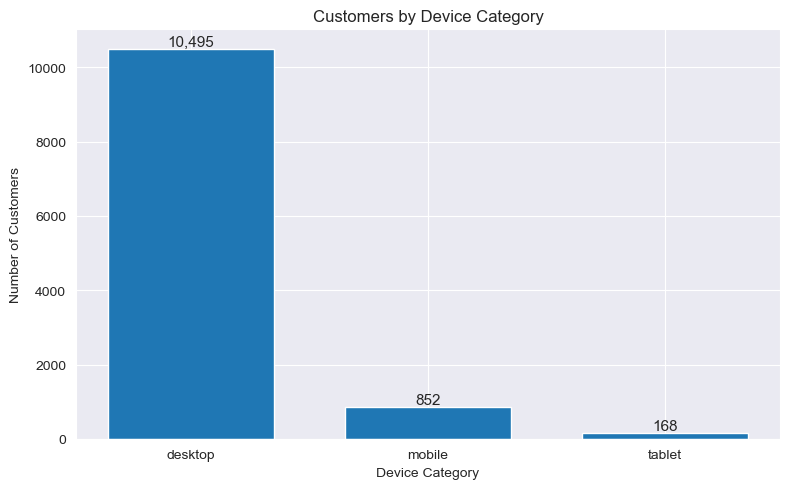

In [97]:
plt.figure(figsize=(8, 5))

bars = plt.bar(device_analysis["deviceCategory"], device_funnel["Customer"], width = 0.7)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height, 
        f"{int(height):,}",
        ha = "center",
        va = "bottom",
        fontsize = 11
    )

plt.title("Customers by Device Category")
plt.xlabel("Device Category")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

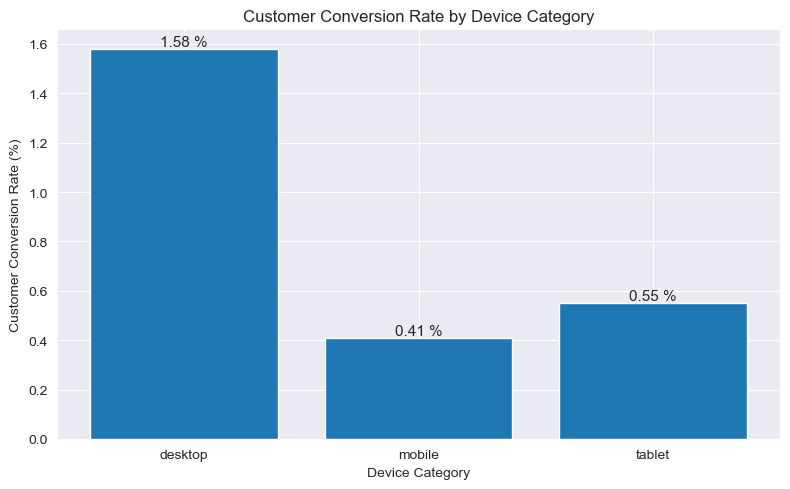

In [98]:
plt.figure(figsize = (8, 5))

bars = plt.bar(device_analysis["deviceCategory"], device_analysis["Customer Conversion Rate (%)"])

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height, 
        f"{height:.2f} %",
        ha = "center",
        va = "bottom",
        fontsize = 11
    )

plt.title("Customer Conversion Rate by Device Category")
plt.xlabel("Device Category")
plt.ylabel("Customer Conversion Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [49]:
# by isMobile
df["isMobile"].value_counts()

isMobile
False    664530
True     239123
Name: count, dtype: int64

In [99]:
mobile_analysis = df.groupby("isMobile", observed = True).agg(Total_Sessions = ("IsCustomer", "size"), Lead_Sessions = ("IsLead", "sum"), Customer_Sessions = ("IsCustomer", "sum")).reset_index()

mobile_analysis["isMobile"] = mobile_analysis["isMobile"].map({
    True: "Mobile",
    False: "Non-Mobile"
})

# Customer Conversion %
mobile_analysis["Customer Conversion Rate (%)"] = (mobile_analysis["Customer_Sessions"] / mobile_analysis["Total_Sessions"] *100).round(2)

# Customer Contribution %
mobile_analysis["Customer Contribution (%)"] = (mobile_analysis["Customer_Sessions"] / mobile_analysis["Customer_Sessions"].sum() * 100).round(2)

mobile_analysis

,isMobile,Total_Sessions,Lead_Sessions,Customer_Sessions,Customer Conversion Rate (%),Customer Contribution (%)
0,Non-Mobile,664530,337409,10495,1.58,91.14
1,Mobile,239123,115614,1020,0.43,8.86


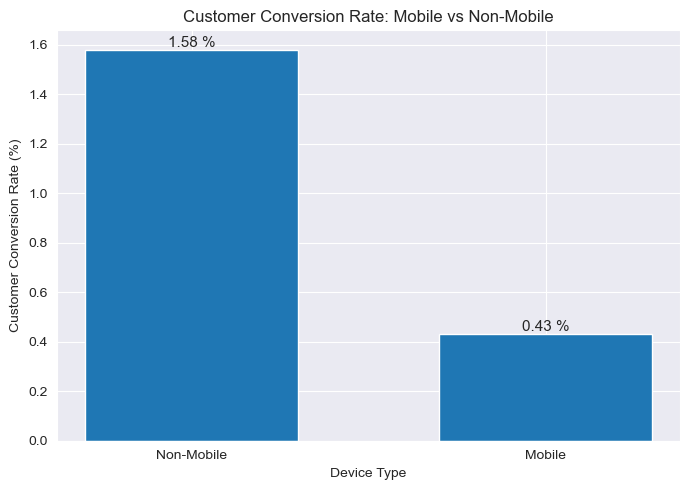

In [101]:
plt.figure(figsize=(7, 5))

bars = plt.bar(mobile_analysis["isMobile"], mobile_analysis["Customer Conversion Rate (%)"], width = 0.6)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height, 
        f"{height:.2f} %",
        ha = "center",
        va = "bottom",
        fontsize = 11
    )

plt.title("Customer Conversion Rate: Mobile vs Non-Mobile")
plt.xlabel("Device Type")
plt.ylabel("Customer Conversion Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [52]:
# browser analysis
browser_counts = df["browser"].value_counts()
browser_counts.head(10)

browser
Chrome               620364
Safari               182245
Firefox               37069
Internet Explorer     19375
Edge                  10205
Android Webview        7865
Safari (in-app)        6850
Opera Mini             6139
Opera                  5643
UC Browser             2427
Name: count, dtype: int64

In [102]:
browser_distribution = df["browser"].value_counts(normalize = True).mul(100).round(2)
browser_distribution.head(10)

browser
Chrome               68.65
Safari               20.17
Firefox               4.10
Internet Explorer     2.14
Edge                  1.13
Android Webview       0.87
Safari (in-app)       0.76
Opera Mini            0.68
Opera                 0.62
UC Browser            0.27
Name: proportion, dtype: float64

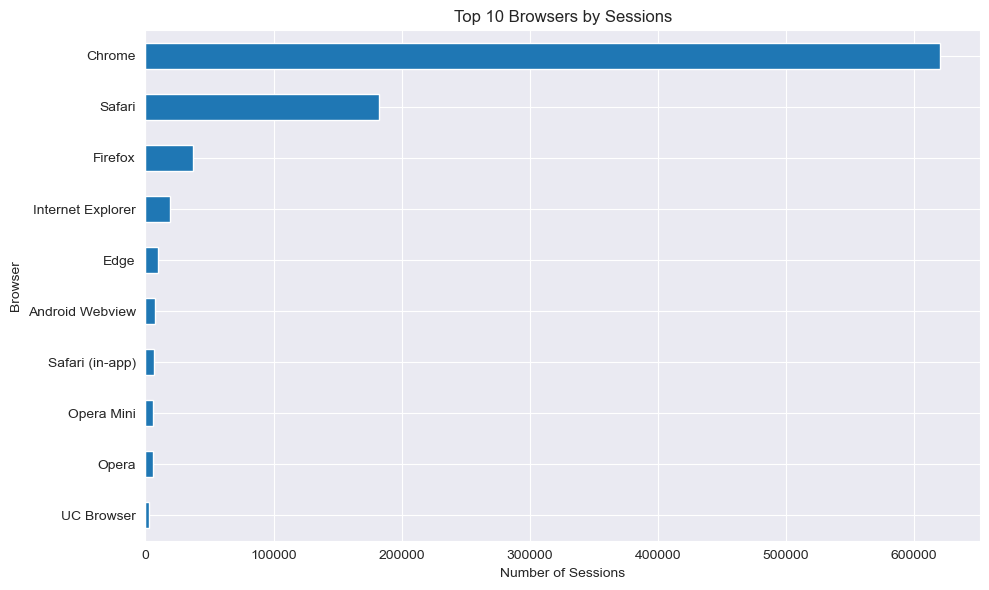

In [103]:
top_browsers = browser_counts.head(10).sort_values()

plt.figure(figsize=(10, 6))

top_browsers.plot(kind="barh")

plt.xlabel("Number of Sessions")
plt.ylabel("Browser")
plt.title("Top 10 Browsers by Sessions")

plt.tight_layout()
plt.show()

In [109]:
browser_analysis = (
    df.groupby("browser", observed = True)
    .agg(
        Total_Sessions = ("IsCustomer", "size"), 
        Lead_Sessions = ("IsLead", "sum"),
        Customer_Sessions = ("IsCustomer", "sum")
    )
    .reset_index()
)

browser_analysis = browser_analysis.sort_values(by = ["Customer_Sessions", "Total_Sessions"], ascending = False).reset_index(drop = True).head(10)

browser_analysis["Customer Conversion Rate (%)"] = (
    browser_analysis["Customer_Sessions"] /
    browser_analysis["Total_Sessions"] * 100
).round(2)

browser_analysis["Customer Contribution %"] = (
    browser_analysis["Customer_Sessions"] /
    browser_analysis["Customer_Sessions"].sum() * 100
).round(2)

browser_analysis

,browser,Total_Sessions,Lead_Sessions,Customer_Sessions,Customer Conversion Rate (%),Customer Contribution %
0,Chrome,620364,329098,10353,1.67,89.91
1,Safari,182245,83860,780,0.43,6.77
2,Firefox,37069,14726,191,0.52,1.66
3,Internet Explorer,19375,7602,109,0.56,0.95
4,Edge,10205,4511,58,0.57,0.50
5,Safari (in-app),6850,2821,12,0.18,0.10
6,Android Webview,7865,3378,6,0.08,0.05
7,Opera,5643,2426,5,0.09,0.04
8,Amazon Silk,561,259,1,0.18,0.01
9,Opera Mini,6139,2122,0,0.00,0.00


In [110]:
os_counts = df["operatingSystem"].value_counts()

os_distribution = (
    df["operatingSystem"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

top_os = pd.DataFrame({
    "Records": os_counts.head(10),
    "Distribution": os_distribution.head(10)
})

top_os

,Records,Distribution
operatingSystem,,
Windows,350072,38.74
Macintosh,253938,28.10
Android,123892,13.71
iOS,107665,11.91
Linux,35034,3.88
Chrome OS,26337,2.91
Unknown,4695,0.52
Windows Phone,1216,0.13
Samsung,280,0.03


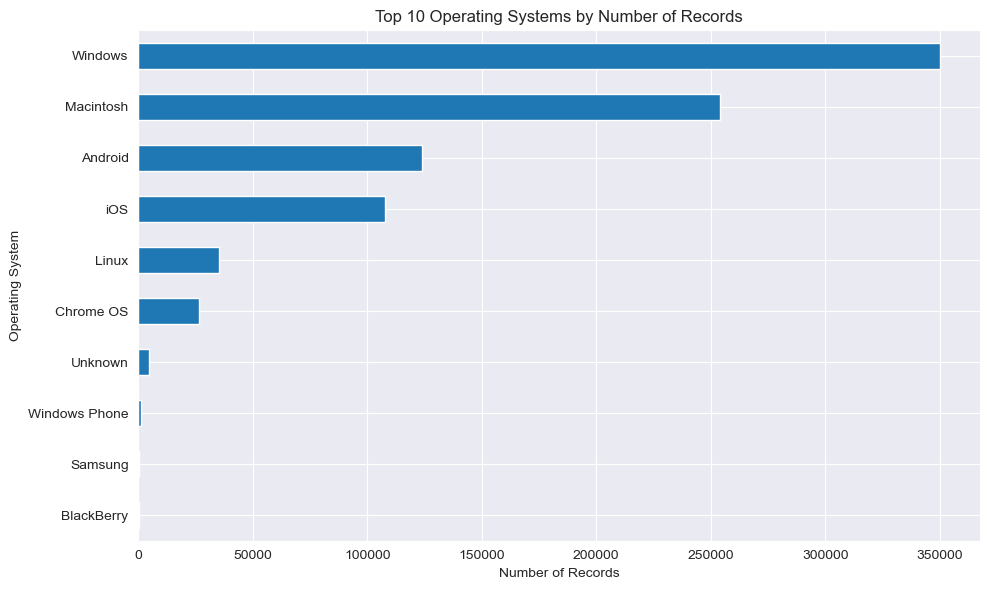

In [58]:
plt.figure(figsize=(10, 6))

top_os["Records"].sort_values().plot(kind="barh")

plt.title("Top 10 Operating Systems by Number of Records")
plt.xlabel("Number of Records")
plt.ylabel("Operating System")
plt.tight_layout()
plt.show()

In [112]:
os_analysis = (
    df.groupby("operatingSystem", observed = True)
    .agg(
        Total_Sessions = ("IsCustomer", "size"),
        Lead_Sessions = ("IsLead", "sum"),
        Customer_Sessions = ("IsCustomer", "sum")
    )
    .reset_index()
)

os_analysis = os_analysis.sort_values(by = ["Customer_Sessions", "Total_Sessions"], ascending = False).reset_index(drop = True).head(10)

os_analysis["Customer Conversion Rate (%)"] = (
    os_analysis["Customer_Sessions"] /
    os_analysis["Total_Sessions"] * 100
).round(2)

os_analysis["Customer Contribution (%)"] = (
    os_analysis["Customer_Sessions"] /
    os_analysis["Customer_Sessions"].sum() * 100
).round(2)

os_analysis

,operatingSystem,Total_Sessions,Lead_Sessions,Customer_Sessions,Customer Conversion Rate (%),Customer Contribution (%)
0,Macintosh,253938,145879,6426,2.53,55.81
1,Windows,350072,154199,2309,0.66,20.05
2,Chrome OS,26337,16665,994,3.77,8.63
3,Linux,35034,21199,782,2.23,6.79
4,iOS,107665,54258,536,0.50,4.65
5,Android,123892,58394,467,0.38,4.06
6,Windows Phone,1216,483,1,0.08,0.01
7,Unknown,4695,1701,0,0.00,0.00
8,Samsung,280,86,0,0.00,0.00
9,BlackBerry,218,60,0,0.00,0.00


#### Geographic analysis

In [60]:
continent_counts = df["continent"].value_counts()
continent_percentage = df["continent"].value_counts(normalize = True).mul(100).round(2)

continent_overview = pd.DataFrame({"Records" : continent_counts, "Percentage" : continent_percentage})
continent_overview

,Records,Percentage
continent,,
Americas,450377,49.84
Asia,223698,24.75
Europe,198311,21.95
Oceania,15054,1.67
Africa,14745,1.63
Unknown,1468,0.16


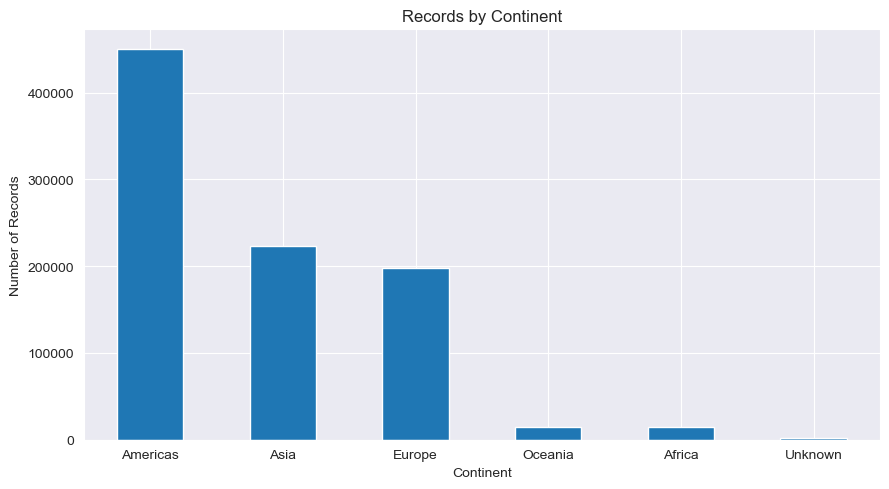

In [61]:
plt.figure(figsize=(9, 5))

continent_counts.plot(kind="bar")

plt.title("Records by Continent")
plt.xlabel("Continent")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [114]:
continent_analysis = (
    df.groupby("continent", observed = True)
    .agg(
        Total_Sessions = ("IsCustomer", "size"),
        Lead_Sessions = ("IsLead", "sum"),
        Customer_Sessions = ("IsCustomer", "sum")
    )
    .reset_index()
)

continent_analysis["Customer Conversion Rate (%)"] = (continent_analysis["Customer_Sessions"] / continent_analysis["Total_Sessions"] * 100).round(2) 
continent_analysis["Customer Contribution (%)"] = (continent_analysis["Customer_Sessions"] / continent_analysis["Customer_Sessions"].sum() * 100).round(2)

continent_analysis = continent_analysis.sort_values(
    "Customer_Sessions",
    ascending=False
)

continent_analysis

,continent,Total_Sessions,Lead_Sessions,Customer_Sessions,Customer Conversion Rate (%),Customer Contribution (%)
1,Americas,450377,276092,11283,2.51,97.99
2,Asia,223698,88817,125,0.06,1.09
3,Europe,198311,75617,79,0.04,0.69
4,Oceania,15054,6760,14,0.09,0.12
0,Africa,14745,5155,8,0.05,0.07
5,Unknown,1468,582,6,0.41,0.05


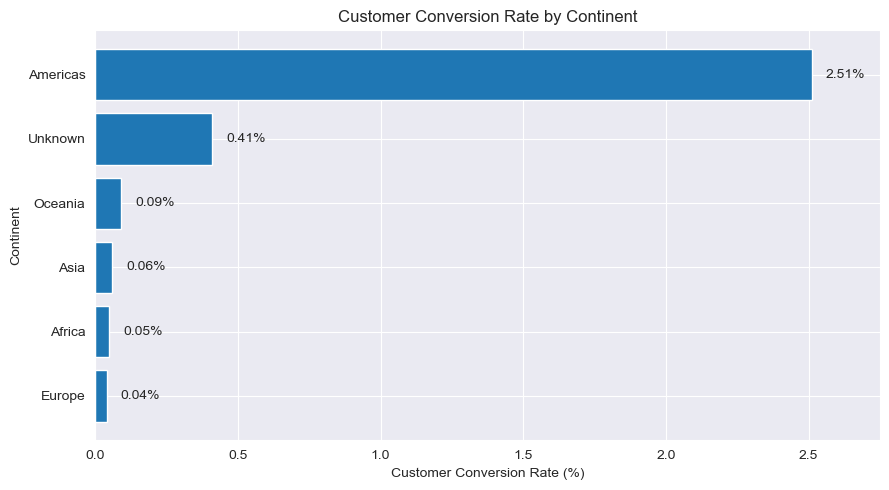

In [118]:
plot_df = continent_analysis.sort_values(
    "Customer Conversion Rate (%)"
)

plt.figure(figsize=(9, 5))

bars = plt.barh(
    plot_df["continent"],
    plot_df["Customer Conversion Rate (%)"]
)

plt.xlabel("Customer Conversion Rate (%)")
plt.ylabel("Continent")
plt.title("Customer Conversion Rate by Continent")
plt.xlim(0,2.75)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}%",
        va="center",
        ha="left"
    )

plt.tight_layout()
plt.show()

In [63]:
# subcontinent analysis

In [64]:
subcontinent_counts = df["subContinent"].value_counts()

subcontinent_percentage = df["subContinent"].value_counts(normalize = True).mul(100).round(2)

top_subcontinents = pd.DataFrame({"Records": subcontinent_counts.head(10), "Percentage": subcontinent_percentage.head(10)})

top_subcontinents

,Records,Percentage
subContinent,,
Northern America,390657,43.23
Southeast Asia,77800,8.61
Southern Asia,59321,6.56
Western Europe,59114,6.54
Northern Europe,58168,6.44
Eastern Asia,46919,5.19
Eastern Europe,45249,5.01
South America,41731,4.62
Western Asia,38443,4.25


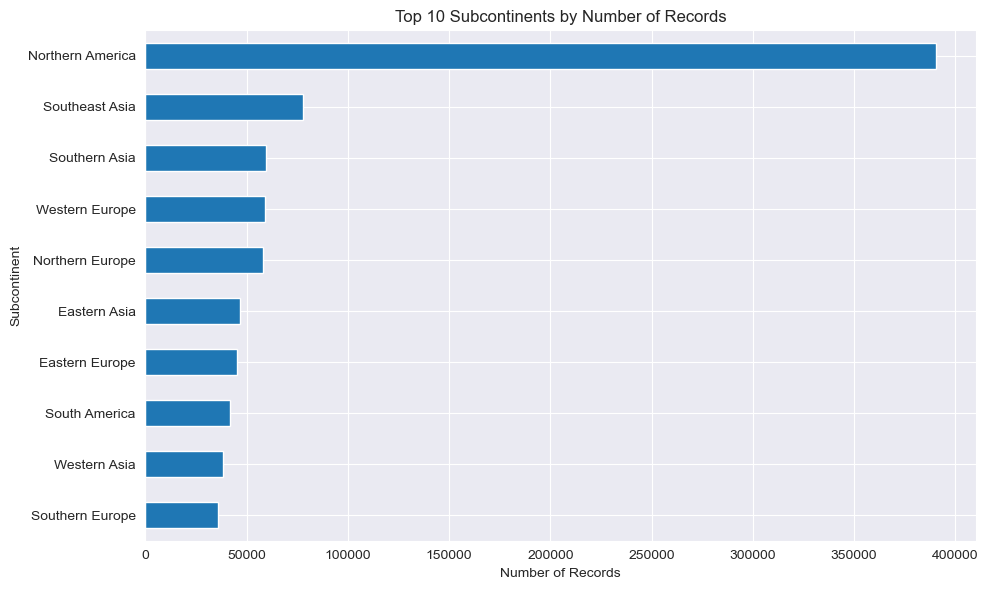

In [65]:
plt.figure(figsize=(10, 6))

top_subcontinents["Records"].sort_values().plot(kind="barh")

plt.title("Top 10 Subcontinents by Number of Records")
plt.xlabel("Number of Records")
plt.ylabel("Subcontinent")
plt.tight_layout()
plt.show()

In [120]:
subcontinent_analysis = (
    df.groupby("subContinent", observed = True)
    .agg(
        Total_Sessions = ("IsCustomer", "size"),
        Lead_Sessions = ("IsLead", "sum"),
        Customer_Sessions = ("IsCustomer", "sum")
    )
    .reset_index()
)

subcontinent_analysis = subcontinent_analysis.sort_values(by = ["Customer_Sessions", "Total_Sessions"], ascending = False).reset_index(drop = True).head(10)

subcontinent_analysis["Customer Conversion Rate (%)"] = (
    subcontinent_analysis["Customer_Sessions"] /
    subcontinent_analysis["Total_Sessions"] * 100
).round(2)

subcontinent_analysis["Customer Contribution (%)"] = (
    subcontinent_analysis["Customer_Sessions"] /
    subcontinent_analysis["Customer_Sessions"].sum() * 100
).round(2)

subcontinent_analysis

,subContinent,Total_Sessions,Lead_Sessions,Customer_Sessions,Customer Conversion Rate (%),Customer Contribution (%)
0,Northern America,390657,253428,11143,2.85,97.18
1,South America,41731,15152,98,0.23,0.85
2,Eastern Asia,46919,20133,59,0.13,0.51
3,Southeast Asia,77800,30588,32,0.04,0.28
4,Western Europe,59114,23558,30,0.05,0.26
5,Northern Europe,58168,23115,27,0.05,0.24
6,Central America,15583,6312,26,0.17,0.23
7,Western Asia,38443,13434,21,0.05,0.18
8,Caribbean,2406,1200,16,0.67,0.14
9,Eastern Europe,45249,15545,14,0.03,0.12


In [67]:
# country analysis

In [121]:
country_counts = df["country"].value_counts()

country_percentage = df["country"].value_counts(normalize = True).mul(100).round(2)

top_countries = pd.DataFrame({"Records" : country_counts.head(10), "Percentage": country_percentage.head(10)})
top_countries

,Records,Percentage
country,,
United States,364744,40.36
India,51140,5.66
United Kingdom,37393,4.14
Canada,25869,2.86
Vietnam,24598,2.72
Turkey,20522,2.27
Thailand,20123,2.23
Germany,19980,2.21
Brazil,19783,2.19


In [122]:
country_analysis = (
    df.groupby("country", observed = True)
    .agg(
        Total_Sessions = ("IsCustomer", "size"),
        Lead_Sessions = ("IsLead", "sum"),
        Customer_Sessions = ("IsCustomer", "sum")
    )
    .reset_index()
)

country_analysis = country_analysis.sort_values(by = ["Customer_Sessions", "Total_Sessions"], ascending = False).reset_index(drop = True).head(10)

country_analysis["Customer Conversion Rate (%)"] = (country_analysis["Customer_Sessions"] / country_analysis["Total_Sessions"] * 100).round(2)
country_analysis["Customer Contribution (%)"] = (country_analysis["Customer_Sessions"] / country_analysis["Customer_Sessions"].sum() * 100).round(2)

country_analysis

,country,Total_Sessions,Lead_Sessions,Customer_Sessions,Customer Conversion Rate (%),Customer Contribution (%)
0,United States,364744,237067,10953,3.00,96.82
1,Canada,25869,16338,190,0.73,1.68
2,Venezuela,2132,954,63,2.95,0.56
3,Mexico,13225,5070,20,0.15,0.18
4,Taiwan,12996,6201,19,0.15,0.17
5,Japan,19731,8385,17,0.09,0.15
6,United Kingdom,37393,14542,16,0.04,0.14
7,Australia,12698,5712,13,0.10,0.11
8,Indonesia,9273,3555,11,0.12,0.10
9,Puerto Rico,732,449,11,1.50,0.10


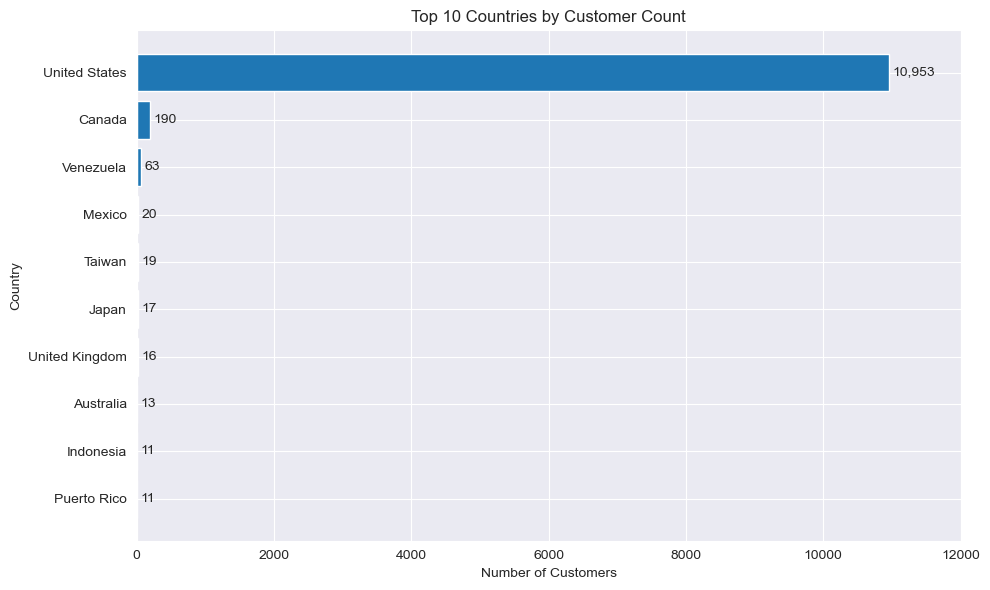

In [125]:
plot_df = country_analysis.sort_values(
    "Customer_Sessions"
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    plot_df["country"],
    plot_df["Customer_Sessions"]
)

plt.xlabel("Number of Customers")
plt.ylabel("Country")
plt.title("Top 10 Countries by Customer Count")
plt.xlim(0, 12000)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 50,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,}",
        va="center",
        ha="left"
    )

plt.tight_layout()
plt.show()

In [126]:
# Time/ Monthly Trend analysis

In [71]:
monthly_records = df["YearMonth"].value_counts().sort_index()

monthly_records

YearMonth
2016-08     74759
2016-09     71032
2016-10     97506
2016-11    113972
2016-12     79124
2017-01     64694
2017-02     62192
2017-03     69931
2017-04     67126
2017-05     65371
2017-06     63578
2017-07     71812
2017-08      2556
Name: count, dtype: int64

In [72]:
monthly_overview = pd.DataFrame({
    "Records": monthly_records,
    "Percentage": (
        monthly_records /
        monthly_records.sum() * 100
    ).round(2)
})

monthly_overview

,Records,Percentage
YearMonth,,
2016-08,74759,8.27
2016-09,71032,7.86
2016-10,97506,10.79
2016-11,113972,12.61
2016-12,79124,8.76
2017-01,64694,7.16
2017-02,62192,6.88
2017-03,69931,7.74
2017-04,67126,7.43


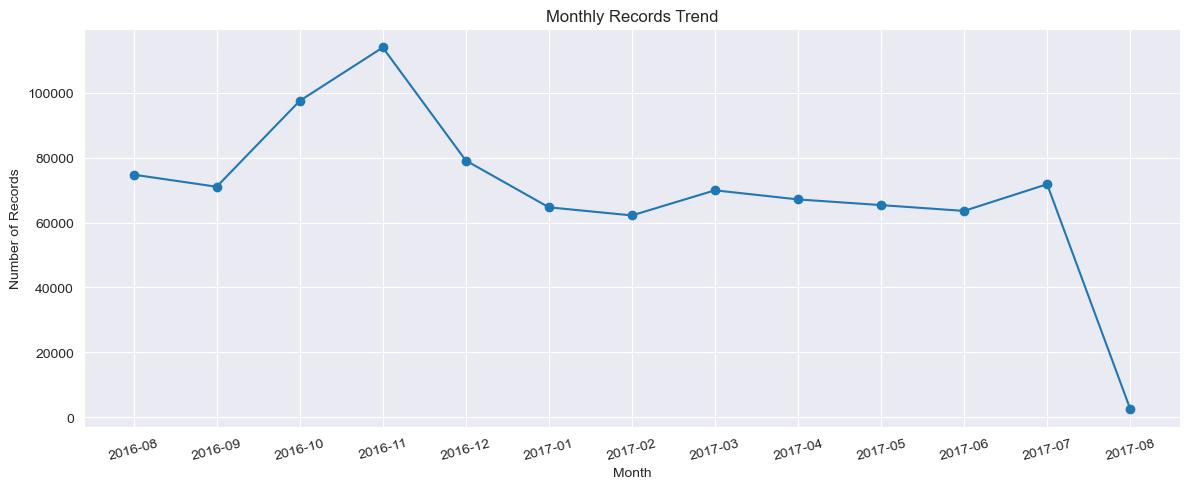

In [73]:
plt.figure(figsize=(12, 5))
x = np.arange(len(monthly_records))
monthly_records.plot(kind="line", marker="o")

plt.title("Monthly Records Trend")
plt.xlabel("Month")
plt.ylabel("Number of Records")
plt.xticks(x, monthly_records.index, rotation = 15)
plt.tight_layout()
plt.show()

In [127]:
monthly_trend_analysis = (
    df.groupby("YearMonth" , observed = True)
    .agg(
        Total_Sessions = ("IsCustomer", "size"),
        Lead_Sessions = ("IsLead", "sum"),
        Customer_Sessions = ("IsCustomer", "sum")
    )
    .reset_index()
)

monthly_trend_analysis["Customer Conversion Rate (%)"] = (
    monthly_trend_analysis["Customer_Sessions"] /
    monthly_trend_analysis["Total_Sessions"] * 100
).round(2)

monthly_trend_analysis["Customer Contribution (%)"] = (
    monthly_trend_analysis["Customer_Sessions"] /
    monthly_trend_analysis["Customer_Sessions"].sum() * 100
).round(2)

monthly_trend_analysis

,YearMonth,Total_Sessions,Lead_Sessions,Customer_Sessions,Customer Conversion Rate (%),Customer Contribution (%)
0,2016-08,74759,38174,1119,1.50,9.72
1,2016-09,71032,36224,859,1.21,7.46
2,2016-10,97506,44893,872,0.89,7.57
3,2016-11,113972,56453,919,0.81,7.98
4,2016-12,79124,43629,1395,1.76,12.11
5,2017-01,64694,33368,697,1.08,6.05
6,2017-02,62192,30913,708,1.14,6.15
7,2017-03,69931,34015,883,1.26,7.67
8,2017-04,67126,32591,928,1.38,8.06
9,2017-05,65371,34166,1115,1.71,9.68


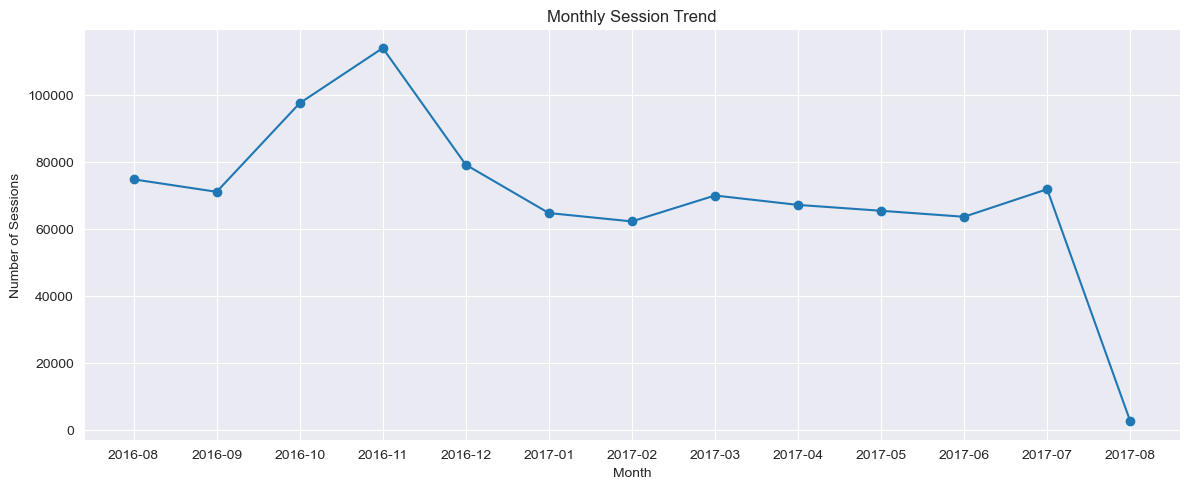

In [134]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_trend_analysis["YearMonth"], monthly_trend_analysis["Total_Sessions"], marker = "o")

plt.xlabel("Month")
plt.ylabel("Number of Sessions")
plt.title("Monthly Session Trend")
plt.tight_layout()
plt.show()

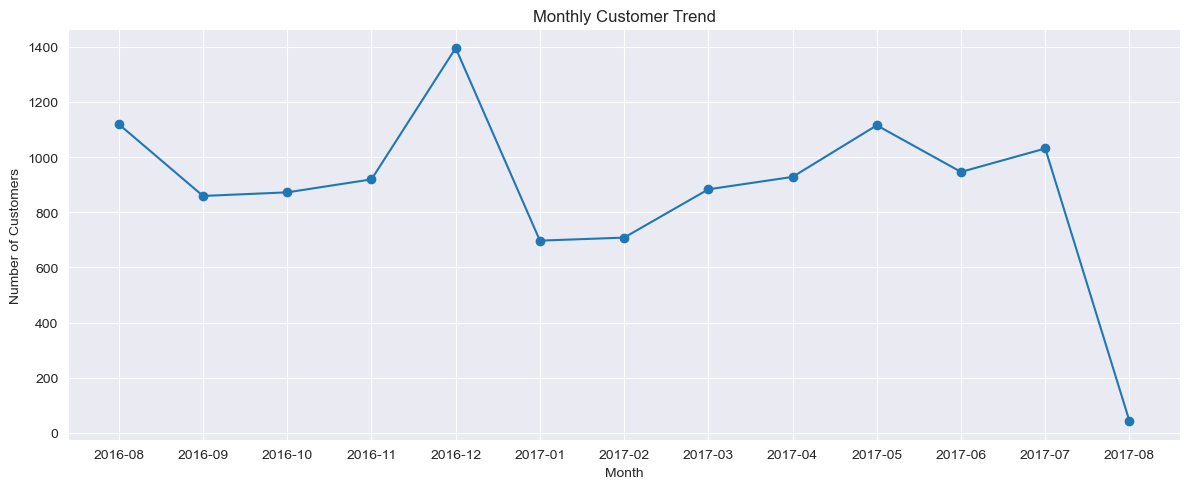

In [133]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_trend_analysis["YearMonth"], monthly_trend_analysis["Customer_Sessions"], marker = "o")

plt.title("Monthly Customer Trend")
plt.xlabel("Month")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

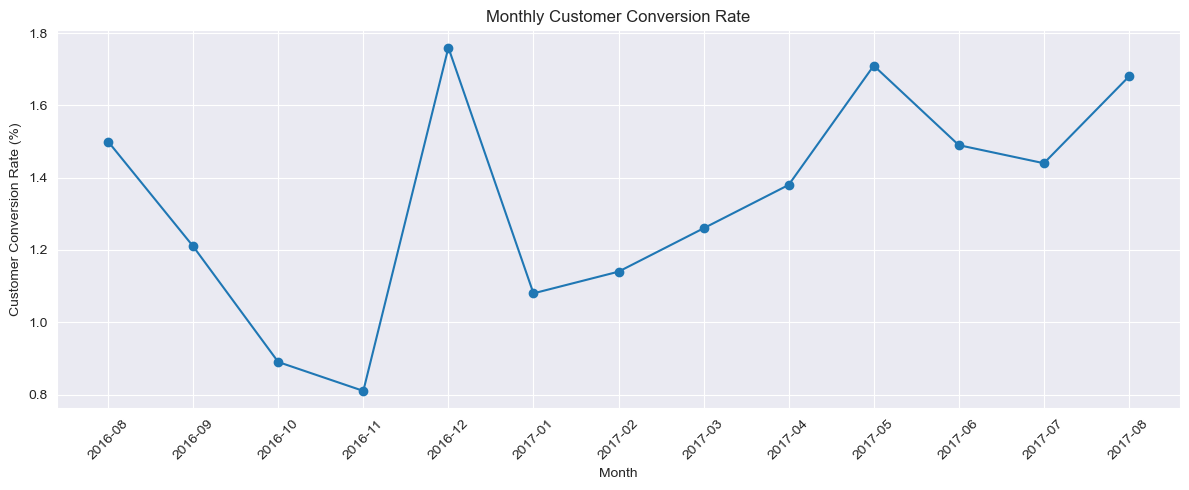

In [137]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_trend_analysis["YearMonth"],
    monthly_trend_analysis["Customer Conversion Rate (%)"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Customer Conversion Rate (%)")
plt.title("Monthly Customer Conversion Rate")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Revenue and Customer Analysis

In [77]:
revenue_summary = df["Revenue"].describe()

print("Revenue Summary:")
display(revenue_summary)

Revenue Summary:


count    903653.000000
mean          1.704273
std          52.778659
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       23129.500000
Name: Revenue, dtype: float64

In [78]:
print("\nTotal Revenue: $", df["Revenue"].sum())
print("Revenue-Generating Records:", (df["Revenue"] > 0).sum())
print("Revenue-Generating Records (%):",
      round((df["Revenue"] > 0).mean() * 100, 2))

print("\nAverage Revenue per Record: $", round(df["Revenue"].mean(), 2))
print("Median Revenue per Record: $", round(df["Revenue"].median(), 2))


Total Revenue: $ 1540071.2400000002
Revenue-Generating Records: 11515
Revenue-Generating Records (%): 1.27

Average Revenue per Record: $ 1.7
Median Revenue per Record: $ 0.0


In [79]:
# revenue among revenue-generating records
customer_revenue = df[df["Revenue"] > 0]["Revenue"]

print("Revenue-Generating Records:", len(customer_revenue))
print("Total Revenue: $", round(customer_revenue.sum(), 2))
print("Average Revenue per Revenue-Generating Record: $",
      round(customer_revenue.mean(), 2))
print("Median Revenue per Revenue-Generating Record: $",
      round(customer_revenue.median(), 2))
print("Maximum Revenue from a Single Record: $",
      round(customer_revenue.max(), 2))

Revenue-Generating Records: 11515
Total Revenue: $ 1540071.24
Average Revenue per Revenue-Generating Record: $ 133.74
Median Revenue per Revenue-Generating Record: $ 49.45
Maximum Revenue from a Single Record: $ 23129.5


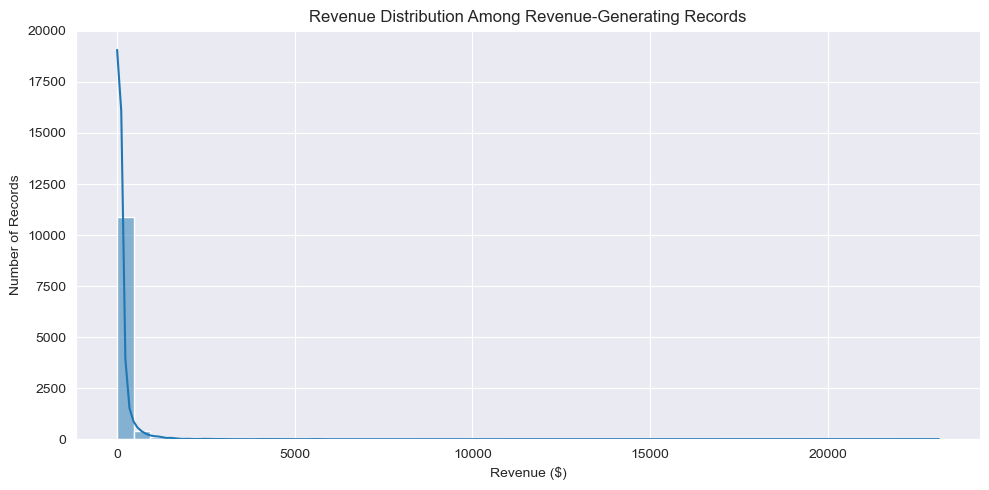

In [80]:
# visualize distribution of revenue among revenue-generating records
plt.figure(figsize=(10, 5))

sns.histplot(
    customer_revenue,
    bins=50,
    kde=True
)

plt.title("Revenue Distribution Among Revenue-Generating Records")
plt.xlabel("Revenue ($)")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

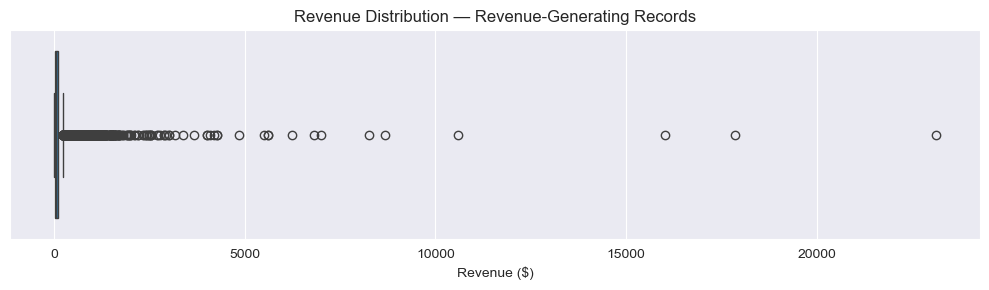

In [81]:
plt.figure(figsize=(10, 3))

sns.boxplot(x=customer_revenue)

plt.title("Revenue Distribution — Revenue-Generating Records")
plt.xlabel("Revenue ($)")
plt.tight_layout()
plt.show()

In [82]:
df["channelGrouping"].value_counts()

channelGrouping
Organic Search    381561
Social            226117
Direct            143026
Referral          104838
Paid Search        25326
Affiliates         16403
Display             6262
(Other)              120
Name: count, dtype: int64

In [83]:
# Revenue by channel
channel_revenue = (
    df.groupby("channelGrouping", observed = True)
    .agg(
        Total_Records = ("Revenue", "size"), 
        Revenue_Generating_Records = ("Revenue", lambda x: (x>0).sum()), 
        Total_Revenue = ("Revenue","sum")
    )
    .reset_index()
)

channel_revenue["Revenue_Contribution_%"] = (
    channel_revenue["Total_Revenue"]
    / channel_revenue["Total_Revenue"].sum()
    * 100
)

channel_revenue["Revenue_per_Revenue_Record"] = (
    channel_revenue["Total_Revenue"]
    / channel_revenue["Revenue_Generating_Records"]
)

channel_revenue = channel_revenue.sort_values(
    "Total_Revenue",
    ascending=False
)

display(channel_revenue)

,channelGrouping,Total_Records,Revenue_Generating_Records,Total_Revenue,Revenue_Contribution_%,Revenue_per_Revenue_Record
6,Referral,104838,5311,651429.91,42.298687,122.656733
2,Direct,143026,2042,434840.55,28.235093,212.948359
4,Organic Search,381561,3438,326380.51,21.192559,94.933249
3,Display,6262,142,78337.46,5.086613,551.672254
5,Paid Search,25326,468,43558.90,2.828369,93.074573
7,Social,226117,104,4916.54,0.319241,47.274423
1,Affiliates,16403,9,597.38,0.038789,66.375556
0,(Other),120,1,9.99,0.000649,9.990000


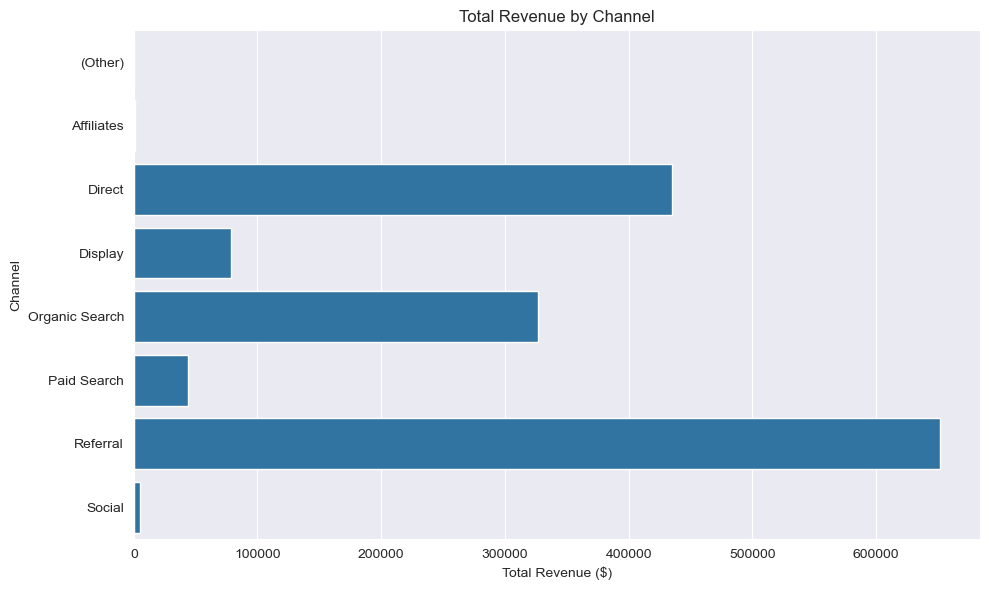

In [84]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=channel_revenue,
    x="Total_Revenue",
    y="channelGrouping"
)

plt.title("Total Revenue by Channel")
plt.xlabel("Total Revenue ($)")
plt.ylabel("Channel")
plt.tight_layout()
plt.show()

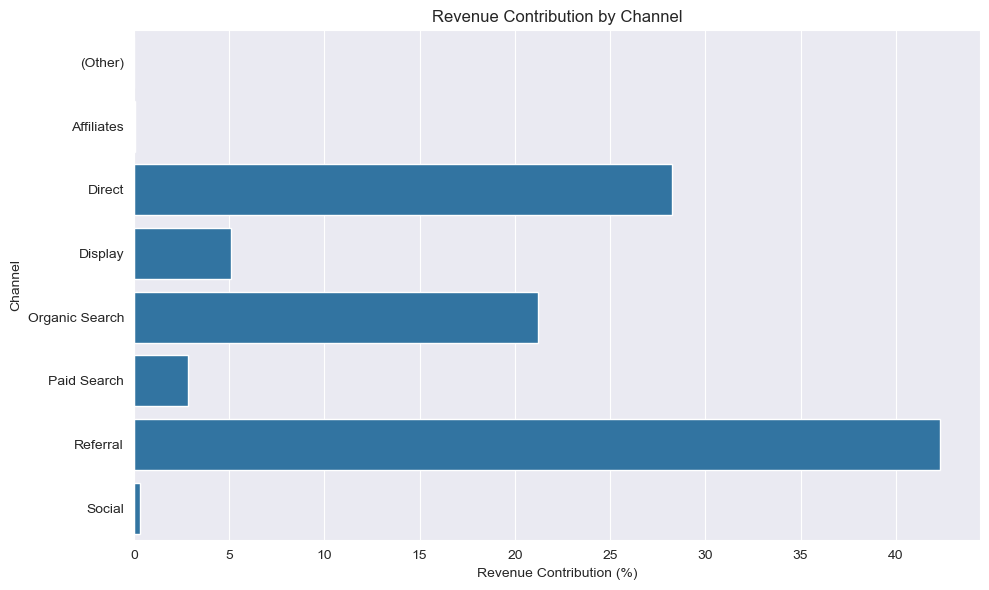

In [85]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=channel_revenue,
    x="Revenue_Contribution_%",
    y="channelGrouping"
)

plt.title("Revenue Contribution by Channel")
plt.xlabel("Revenue Contribution (%)")
plt.ylabel("Channel")
plt.tight_layout()
plt.show()

In [86]:
# Revenue by device

device_revenue = (
    df.groupby(
        "deviceCategory",
        observed = True
    )
    .agg(
        Total_Records = ("Revenue", "size"),
        Revenue_Generating_Records = ("Revenue", lambda x: (x>0).sum()),
        Total_Revenue = ("Revenue", "sum")
    )
    .reset_index()
)

device_revenue["Revenue_Contribution_%"] = device_revenue["Total_Revenue"] / device_revenue["Total_Revenue"].sum() * 100

device_revenue["Revenue_Per_Revenue_Record"] = device_revenue["Total_Revenue"] / device_revenue["Revenue_Generating_Records"] 

device_revenue = device_revenue.sort_values(
    "Total_Revenue",
    ascending=False
)

display(device_revenue)

,deviceCategory,Total_Records,Revenue_Generating_Records,Total_Revenue,Revenue_Contribution_%,Revenue_Per_Revenue_Record
0,desktop,664479,10495,1480864.09,96.155558,141.101867
1,mobile,208725,852,49785.81,3.232695,58.434049
2,tablet,30449,168,9421.34,0.611747,56.079405


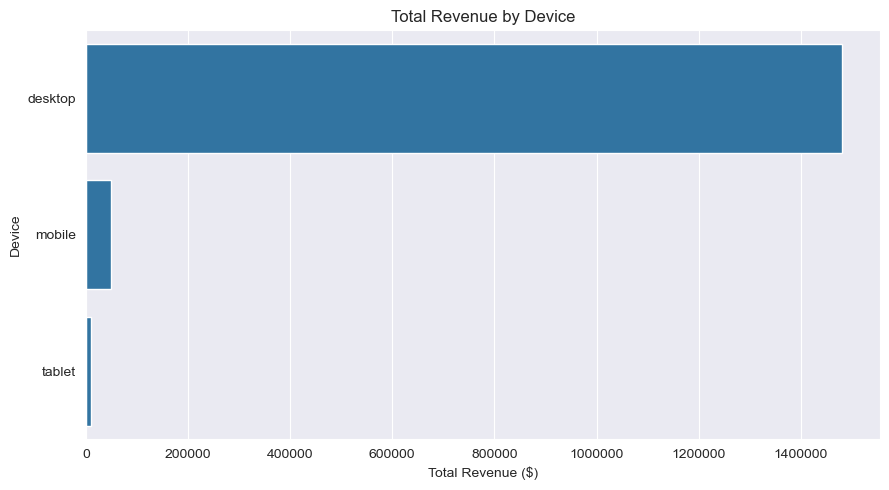

In [87]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=device_revenue,
    x="Total_Revenue",
    y="deviceCategory"
)

formatter = ScalarFormatter(useOffset=False)
formatter.set_scientific(False)
ax.xaxis.set_major_formatter(formatter)

plt.title("Total Revenue by Device")
plt.xlabel("Total Revenue ($)")
plt.ylabel("Device")
plt.tight_layout()
plt.show()

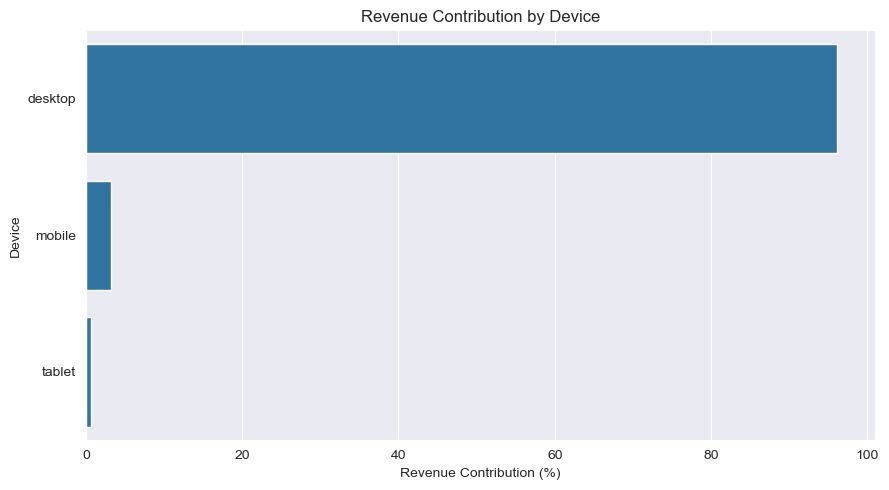

In [88]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=device_revenue,
    x="Revenue_Contribution_%",
    y="deviceCategory"
)

plt.title("Revenue Contribution by Device")
plt.xlabel("Revenue Contribution (%)")
plt.ylabel("Device")
plt.tight_layout()
plt.show()

In [89]:
# Revenue by Geography
continent_revenue = (
    df.groupby(
        "continent",
        observed = True
    )
    .agg(
        Total_Records = ("Revenue", "size"),
        Revenue_Generated_Records = ("Revenue", lambda x: (x>0).sum()),
        Total_Revenue = ("Revenue", "sum")
    )
    .reset_index()
)

continent_revenue["Revenue_Contribution_%"] = continent_revenue["Total_Revenue"] / continent_revenue["Total_Revenue"].sum() * 100

continent_revenue["Revenue_Per_Revenue_Record"] = continent_revenue["Total_Revenue"] / continent_revenue["Revenue_Generated_Records"] 

continent_revenue = continent_revenue.sort_values("Total_Revenue", ascending = False)

display(continent_revenue)

,continent,Total_Records,Revenue_Generated_Records,Total_Revenue,Revenue_Contribution_%,Revenue_Per_Revenue_Record
1,Americas,450377,11283,1504671.60,97.701428,133.357405
2,Asia,223698,125,17401.84,1.129937,139.214720
0,Africa,14745,8,8687.76,0.564114,1085.970000
3,Europe,198311,79,6747.03,0.438099,85.405443
4,Oceania,15054,14,1793.23,0.116438,128.087857
5,Unknown,1468,6,769.78,0.049983,128.296667


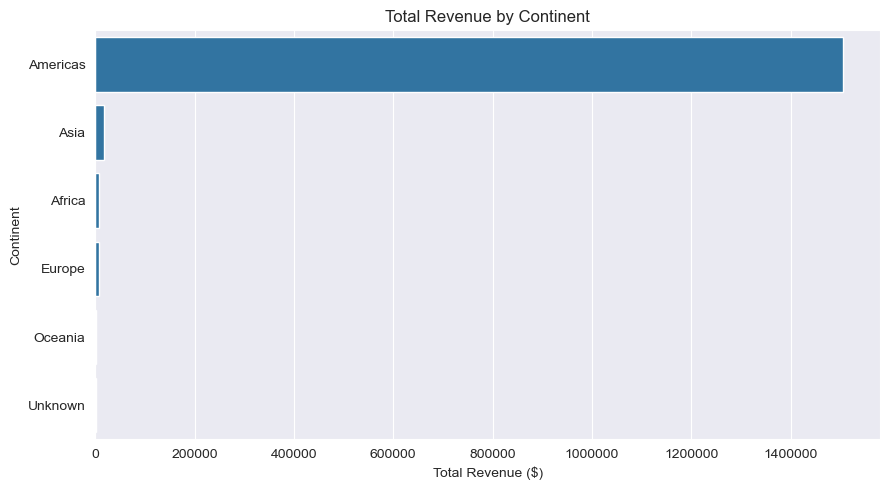

In [90]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=continent_revenue,
    x="Total_Revenue",
    y="continent",
    order = continent_revenue["continent"].to_list()
)

formatter = ScalarFormatter(useOffset=False)
formatter.set_scientific(False)
ax.xaxis.set_major_formatter(formatter)

plt.title("Total Revenue by Continent")
plt.xlabel("Total Revenue ($)")
plt.ylabel("Continent")

plt.tight_layout()
plt.show()

In [91]:
country_revenue = (
    df.groupby("country", observed = True)
    .agg(
        Total_Records = ("Revenue", "size"),
        Revenue_Generated_Records = ("Revenue", lambda x: (x>0).sum()),
        Total_Revenue = ("Revenue", "sum")
    )
    .reset_index()
)

country_revenue["Revenue_Contribution_%"] = country_revenue["Total_Revenue"] / country_revenue["Total_Revenue"].sum() * 100

country_revenue["Revenue_Per_Revenue_Record"] = country_revenue["Total_Revenue"] / country_revenue["Revenue_Generated_Records"] 

top10_country_revenue = (
    country_revenue.sort_values(
        "Total_Revenue",
        ascending = False
    )
    .head(10)
    .reset_index(drop = True)
)

display(top10_country_revenue)

,country,Total_Records,Revenue_Generated_Records,Total_Revenue,Revenue_Contribution_%,Revenue_Per_Revenue_Record
0,United States,364744,10953,1452440.65,94.309965,132.606651
1,Canada,25869,190,32824.54,2.131365,172.760737
2,Venezuela,2132,63,13374.90,0.868460,212.300000
3,Japan,19731,17,6728.99,0.436927,395.822941
4,Kenya,771,3,5268.70,0.342108,1756.233333
5,Nigeria,1446,2,3302.40,0.214432,1651.200000
6,Taiwan,12996,19,1920.89,0.124727,101.099474
7,Indonesia,9273,11,1840.38,0.119500,167.307273
8,Australia,12698,13,1745.26,0.113323,134.250769
9,United Kingdom,37393,16,1689.45,0.109699,105.590625


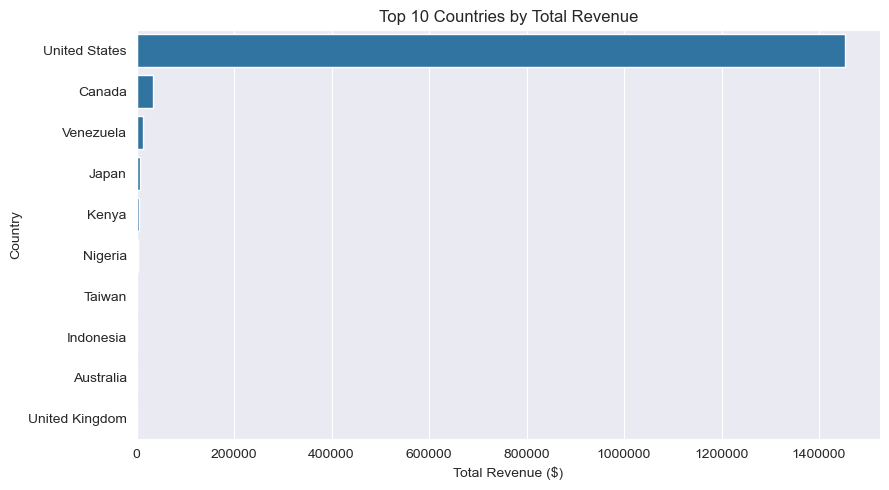

In [92]:
plt.figure(figsize = (9,5))

ax = sns.barplot(
    data=top10_country_revenue,
    x="Total_Revenue",
    y="country",
    order=top10_country_revenue["country"].tolist()
)

formatter = ScalarFormatter(useOffset = False)
formatter.set_scientific(False)
ax.xaxis.set_major_formatter(formatter)

plt.title("Top 10 Countries by Total Revenue")
plt.xlabel("Total Revenue ($)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [93]:
# Revenue by Month
# Phase 9.6 — Revenue by Month

monthly_revenue = (
    df.groupby("YearMonth", observed = True)
      .agg(
          Total_Records=("Revenue", "size"),
          Revenue_Generating_Records=("Revenue", lambda x: (x > 0).sum()),
          Total_Revenue=("Revenue", "sum")
      )
      .reset_index()
)

monthly_revenue["Revenue_Contribution_%"] = (
    monthly_revenue["Total_Revenue"]
    / monthly_revenue["Total_Revenue"].sum()
    * 100
)

monthly_revenue["Revenue_per_Revenue_Record"] = (
    monthly_revenue["Total_Revenue"]
    / monthly_revenue["Revenue_Generating_Records"]
)

display(monthly_revenue)

,YearMonth,Total_Records,Revenue_Generating_Records,Total_Revenue,Revenue_Contribution_%,Revenue_per_Revenue_Record
0,2016-08,74759,1119,154666.56,10.042819,138.218552
1,2016-09,71032,859,126031.24,8.183468,146.718556
2,2016-10,97506,872,113329.07,7.358690,129.964530
3,2016-11,113972,919,119013.87,7.727816,129.503667
4,2016-12,79124,1395,154557.93,10.035765,110.794215
5,2017-01,64694,697,97877.79,6.355407,140.427245
6,2017-02,62192,708,108756.52,7.061785,153.610904
7,2017-03,69931,883,130964.27,8.503780,148.317407
8,2017-04,67126,928,158788.80,10.310484,171.108621
9,2017-05,65371,1115,121711.48,7.902977,109.158278


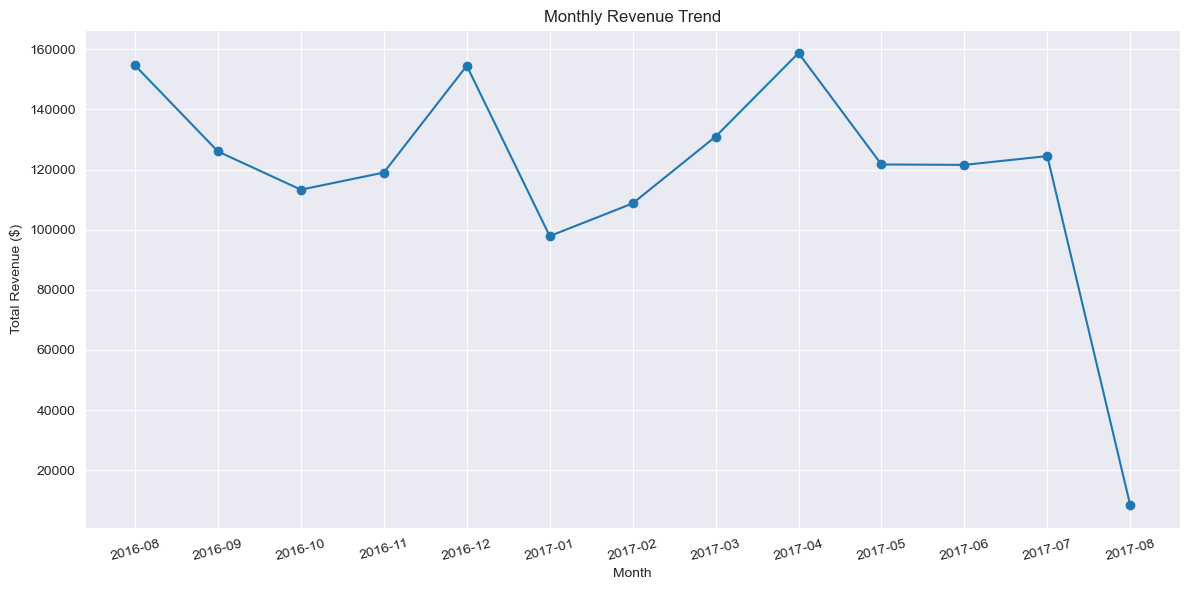

In [94]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue["YearMonth"].astype(str),
    monthly_revenue["Total_Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=15)

formatter = ScalarFormatter(useOffset=False)
formatter.set_scientific(False)
ax.yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

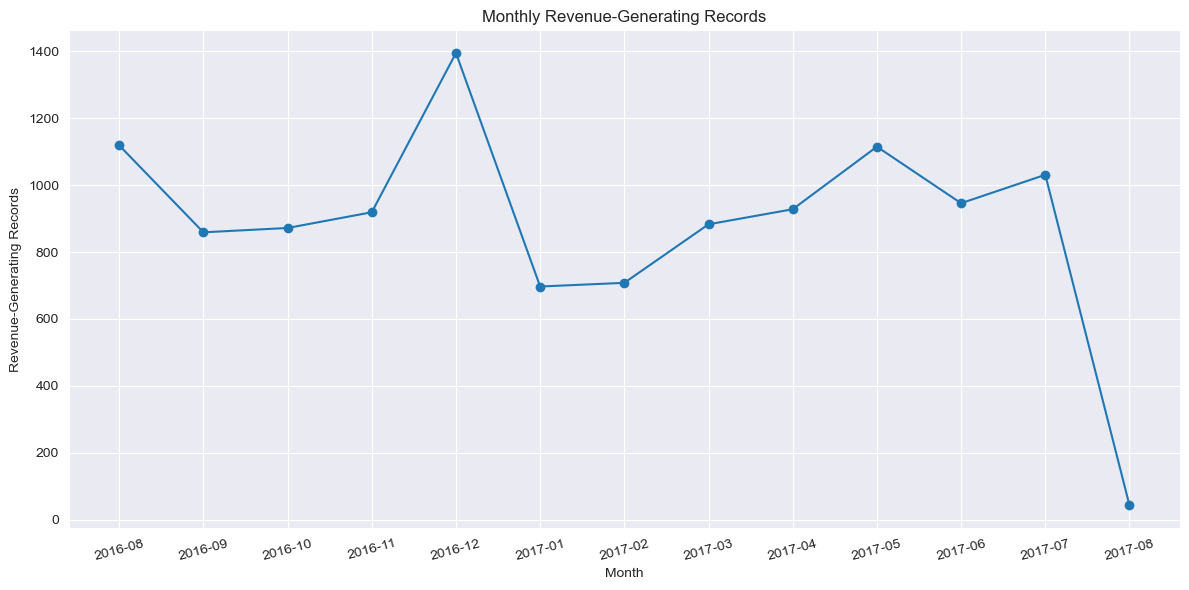

In [95]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue["YearMonth"],
    monthly_revenue["Revenue_Generating_Records"],
    marker="o"
)

plt.title("Monthly Revenue-Generating Records")
plt.xlabel("Month")
plt.ylabel("Revenue-Generating Records")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

# Findings & Business Recommendations

This section summarizes the key findings obtained from the analysis performed in the previous sections. The objective is to convert the analytical results into meaningful business insights and recommendations based on funnel performance, channel performance, source and medium analysis, device and user behavior, geographic performance, monthly trends, and revenue analysis.

## Overall Business Findings

The overall analysis shows that customer conversion is the major area of opportunity.

The corrected funnel analysis showed:

| Funnel Transition | Conversion Rate | Drop-off Rate |
|---|---:|---:|
| Visitor → Lead | 50.13% | 49.87% |
| Lead → Customer | 2.54% | 97.46% |

Approximately half of all sessions progressed to the Lead stage. However, only 2.54% of Lead sessions resulted in customers. Therefore, the largest drop-off occurs between the **Lead and Customer stages**.

**Key Finding:** The business should focus not only on attracting more visitors but also on improving the conversion of existing leads into customers.

**Business Recommendation:** The Lead → Customer stage should be investigated further. Potential areas for investigation include landing-page effectiveness, product-page experience, calls-to-action, checkout experience, and other sources of purchase friction.

## Channel Performance Findings

The channel analysis shows significant differences in customer performance across marketing channels.

| Channel | Sessions | Customers | Conversion Rate | Customer Contribution |
|---|---:|---:|---:|---:|
| Referral | 104,838 | 5,311 | 5.07% | 46.12% |
| Organic Search | 381,561 | 3,438 | 0.90% | 29.86% |
| Direct | 143,026 | 2,042 | 1.43% | 17.73% |
| Paid Search | 25,326 | 468 | 1.85% | 4.06% |
| Display | 6,262 | 142 | 2.27% | 1.23% |
| Social | 226,117 | 104 | 0.05% | 0.90% |

### Key Findings

- **Referral** was the strongest-performing channel, generating 5,311 customers and contributing 46.12% of all customers.
- **Organic Search** generated the highest number of sessions among the major channels but had a lower customer conversion rate of 0.90%.
- **Social** generated substantial traffic but had a very low customer conversion rate of 0.05%.
- High traffic volume does not necessarily result in high customer conversion.

### Business Recommendations

1. Continue evaluating and strengthening high-performing referral sources.
2. Investigate why referral traffic converts more effectively.
3. Review the quality and conversion performance of Social traffic.
4. Evaluate channels using both traffic volume and customer conversion rather than traffic alone.

## Source and Medium Findings

The source and medium analysis provides a more detailed view of traffic performance.

### Key Findings

- Referral was the strongest medium in terms of customer contribution, generating **47.03% of all customers**.
- Organic generated the highest traffic volume with **381,561 sessions**, but its customer conversion rate was **0.90%**.
- At the source level, **google** generated the highest number of sessions with **400,788 sessions**.
- **mall.googleplex.com** generated **5,103 customers** and had a customer conversion rate of **7.68%**.
- Google generated significantly more traffic but had a lower customer conversion rate of **0.97%**.

### Business Recommendation

Marketing performance should be evaluated at both the **channel level and source/medium level**. High-traffic sources should not automatically be considered the most effective sources because traffic volume and customer conversion can differ substantially.

## Device and User Findings

The device analysis showed substantial differences in customer conversion across devices.

| Device | Sessions | Customers | Conversion Rate |
|---|---:|---:|---:|
| Desktop | 664,479 | 10,495 | 1.58% |
| Mobile | 208,725 | 852 | 0.41% |
| Tablet | 30,449 | 168 | 0.55% |

### Key Findings

- Desktop generated **10,495 customers** and contributed **91.14% of all customers**.
- Mobile generated a substantial amount of traffic but had a much lower conversion rate of **0.41%**.
- Chrome dominated browser usage and contributed **89.91% of customers**.
- Macintosh users generated the highest number of customers among operating systems, while Chrome OS had the highest observed conversion rate.

### Business Recommendations

1. Investigate the mobile user journey because mobile conversion is considerably lower than desktop conversion.
2. Review mobile page usability, navigation, calls-to-action, and checkout experience.
3. Continue monitoring performance across major browsers and operating systems.

The dataset identifies differences in performance but does not establish the exact reasons behind those differences.

## Geographic Findings

Customer activity was highly concentrated geographically.

### Key Findings

- The **Americas** generated 450,377 sessions and contributed **97.99% of all customers**.
- **Northern America** contributed **97.18% of all customers**.
- The **United States** generated 10,953 customers and contributed **96.82% of all customers**.
- The United States had a customer conversion rate of **3.00%**.
- India generated **51,140 sessions** but produced relatively few customers compared with the United States.

### Business Recommendations

1. Continue focusing on high-performing markets such as the United States and North America.
2. Investigate high-traffic but low-converting geographic markets.
3. Consider whether localization, user experience, marketing relevance, or other market-specific factors may influence conversion.

The available dataset shows the geographic differences but does not identify the exact reasons for those differences.

## Monthly Performance Findings

The monthly analysis showed that traffic volume and customer performance did not always move together.

### Key Findings

- **November 2016** recorded the highest traffic volume with **113,972 sessions**.
- However, November had a relatively low customer conversion rate of **0.81%**.
- **December 2016** generated the highest number of customers among complete months, with **1,395 customers**.
- December also recorded the highest complete-month customer conversion rate of **1.76%**.
- **May 2017** also performed strongly with **1,115 customers** and a **1.71%** conversion rate.
- August 2017 is a partial month because the dataset ends on August 1, 2017.

### Key Insight

Higher traffic volume does not necessarily result in higher customer conversion.

### Business Recommendation

Monthly performance should be evaluated using multiple KPIs, including:

- Sessions
- Leads
- Customers
- Customer conversion rate
- Revenue

rather than relying on traffic volume alone.

## Revenue Findings

The revenue analysis showed that revenue was highly concentrated among a small number of channels.

### Total Revenue

**$1,540,071.24**

### Revenue by Channel

| Channel | Total Revenue | Revenue Contribution |
|---|---:|---:|
| Referral | $651,429.91 | 42.30% |
| Direct | $434,840.55 | 28.24% |
| Organic Search | $326,380.51 | 21.19% |
| Display | $78,337.46 | 5.09% |
| Paid Search | $43,558.90 | 2.83% |

Referral, Direct, and Organic Search together generated approximately **91.73% of total revenue**.

### Key Finding

A relatively small number of channels account for the majority of revenue.

### Business Recommendation

These major revenue-generating channels should receive particular attention when evaluating marketing performance. However, revenue contribution should be considered together with conversion rate and traffic volume before making resource-allocation decisions.

## Most Important Business Insights

After combining the results from all analysis sections, the following are the most important insights:

1. **Lead-to-Customer conversion is the biggest funnel problem.**  
   Only 2.54% of Lead sessions resulted in customers.

2. **Referral is the strongest customer-generating channel.**  
   Referral contributed 46.12% of all customers and had a 5.07% customer conversion rate.

3. **High traffic does not guarantee high conversion.**  
   Social generated substantial traffic but had only a 0.05% customer conversion rate.

4. **Desktop users dominate customer activity.**  
   Desktop contributed 91.14% of all customers.

5. **Customer activity is highly concentrated geographically.**  
   The United States contributed 96.82% of all customers.

6. **Traffic and customer performance vary over time.**  
   November 2016 had the highest traffic, while December 2016 had the highest complete-month customer count and conversion rate.

7. **Revenue is concentrated in a few channels.**  
   Referral, Direct, and Organic Search together generated approximately 91.73% of total revenue.

## Final Business Recommendations

Based on the complete analysis, the following recommendations can be made:

### 1. Improve Lead → Customer Conversion

The largest funnel drop-off occurs between the Lead and Customer stages. The business should investigate the factors preventing leads from completing a purchase.

### 2. Strengthen Referral Performance

Referral is the strongest customer-generating channel. Successful referral sources should be identified and evaluated for further opportunities.

### 3. Investigate Mobile Conversion

Mobile has substantial traffic but a considerably lower customer conversion rate than desktop. The mobile user journey should therefore be investigated.

### 4. Optimize High-Traffic but Low-Converting Sources

Traffic-generating sources should not be evaluated using traffic volume alone. Sources with high traffic but low conversion should be reviewed for traffic quality and user experience.

### 5. Focus on High-Value Geographic Markets

The United States and North America account for the majority of customers and should remain important markets while other high-traffic but low-converting regions are investigated.

### 6. Evaluate Revenue Alongside Conversion

Marketing decisions should consider the complete journey:

**Traffic → Leads → Customers → Revenue**

rather than relying on a single metric.

## Final Project Conclusion

The analysis of Google Analytics customer behavior shows that customer conversion varies substantially across the funnel, marketing channels, devices, geographic regions, and time periods.

Approximately **50.13% of sessions progressed to the Lead stage**, but only **2.54% of Lead sessions resulted in customers**, making Lead-to-Customer conversion the primary area for improvement.

Referral was the strongest-performing channel, contributing **46.12% of customers**, while Social generated substantial traffic but had a very low customer conversion rate. Desktop users dominated customer activity, contributing **91.14% of customers**, while customer activity was highly concentrated in the United States and North America.

Revenue was also concentrated, with Referral, Direct, and Organic Search contributing approximately **91.73% of total revenue**.

Overall, the findings demonstrate that increasing traffic alone is not sufficient to improve business performance. Improving conversion quality, strengthening high-performing channels, investigating mobile performance, and focusing on high-value markets are important opportunities for improving customer and revenue outcomes.